# Cash Flow Forecasting Data Analysis
## Understanding Data Constraints for Hierarchical Forecasting

**Objective:** Analyze the data distribution to understand why forecasting at granular hierarchical levels (account_name + level5 or level2) presents significant challenges due to data sparsity.

---

### Key Questions to Answer:
1. How many unique combinations exist at each hierarchical level?
2. What is the data point distribution per combination?
3. What percentage of combinations have insufficient data for ML forecasting?
4. What are the implications for forecast accuracy?

---

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading & Initial Exploration

In [2]:
# Load the dataset
data = pd.read_csv(r'D:\PivotX_advisors\ai_cashflow_new_final.csv', low_memory=False)

print(f"Total Dataset Shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
print(f"\nDataset Memory Usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Total Dataset Shape: 174,453 rows × 44 columns

Dataset Memory Usage: 465.65 MB


In [3]:
print(data.columns.to_list())

['flow_category', 'bank_branch_id', 'source', 'instance', 'account', 'account_business_id', 'id', 'source_primary_key', 'source_file_name', 'account_identifier', 'transaction_currency', 'transaction_amount', 'value_datetime', 'booking_datetime', 'description', 'extended_details', 'canonical_update_timestamp', 'account_name', 'account_alternative_name', 'account_holder', 'account_holder_id', 'account_class', 'cash_pool_role', 'cash_pool_name', 'bank_name', 'account_currency', 'entity_country', 'entity_name', 'entity_alternative_name', 'entity_code', 'entity_currency', 'entity_region', 'entity_top_level', 'branch_name', 'level1', 'level2', 'level3', 'level4', 'level5', 'fx_rate', 'transaction_amount_usd', 'forecast_flag', 'opcos', 'period_month']


In [4]:
print(data['forecast_flag'].nunique)

<bound method IndexOpsMixin.nunique of 0         ai_forecast
1         ai_forecast
2         ai_forecast
3         ai_forecast
4         ai_forecast
             ...     
174448        actuals
174449        actuals
174450        actuals
174451        actuals
174452        actuals
Name: forecast_flag, Length: 174453, dtype: object>


In [5]:
# Focus on important columns for forecasting
important_columns = [
    'flow_category', 'source', 'transaction_currency', 'transaction_amount',
    'value_datetime', 'account_name', 'bank_name', 'entity_country',
    'entity_name', 'entity_region', 'level2', 'level5', 'fx_rate',
    'transaction_amount_usd', 'opcos'
]

# Select only important columns
df = data[important_columns].copy()

print(f"Working Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n" + "="*60)
print("COLUMN DATA TYPES:")
print("="*60)
print(df.dtypes)

Working Dataset Shape: 174,453 rows × 15 columns

COLUMN DATA TYPES:
flow_category              object
source                     object
transaction_currency       object
transaction_amount        float64
value_datetime             object
account_name               object
bank_name                  object
entity_country             object
entity_name                object
entity_region              object
level2                     object
level5                     object
fx_rate                   float64
transaction_amount_usd    float64
opcos                      object
dtype: object


In [6]:
# Missing Values Analysis
print("="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Non-Null Count': df.notnull().sum().values
})
missing_summary = missing_summary.sort_values('Missing %', ascending=False)

print(missing_summary.to_string(index=False))

MISSING VALUES ANALYSIS
                Column  Missing Count  Missing %  Non-Null Count
    transaction_amount          40097      22.98          134356
        value_datetime          40097      22.98          134356
         flow_category          37752      21.64          136701
               fx_rate          33909      19.44          140544
                level2          33845      19.40          140608
             bank_name          33800      19.37          140653
  transaction_currency          33800      19.37          140653
                 opcos           6565       3.76          167888
                source           6297       3.61          168156
transaction_amount_usd             70       0.04          174383
                level5             45       0.03          174408
          account_name              0       0.00          174453
         entity_region              0       0.00          174453
        entity_country              0       0.00          174453
 

## 2. Filter to Actual Transaction Data (OAT Source)

In [7]:
# Check source distribution
print("="*60)
print("SOURCE DISTRIBUTION (Before Filtering)")
print("="*60)

source_dist = df['source'].value_counts(dropna=False)
source_pct = (source_dist / len(df) * 100).round(2)

for src, count in source_dist.items():
    pct = source_pct[src]
    print(f"  {str(src):15} : {count:>10,} records ({pct:>5.2f}%)")

SOURCE DISTRIBUTION (Before Filtering)
  OAT             :    134,356 records (77.02%)
  Forecast        :     33,800 records (19.37%)
  nan             :      6,297 records ( 3.61%)


In [8]:
# Filter to OAT (actual transactions) only
df = df[df['source'] == 'OAT'].copy()

print(f"After filtering to OAT source: {len(df):,} records")

# Drop rows with missing critical values
df = df.dropna(subset=['transaction_amount_usd'])
print(f"After dropping null transaction_amount_usd: {len(df):,} records")

df = df.dropna(subset=['level2'])
print(f"After dropping null level2: {len(df):,} records")

df = df.dropna(subset=['level5'])
print(f"After dropping null level5: {len(df):,} records")

df = df.dropna(subset=['opcos'])
print(f"After dropping null opcos: {len(df):,} records")

After filtering to OAT source: 134,356 records
After dropping null transaction_amount_usd: 134,286 records
After dropping null level2: 134,241 records
After dropping null level5: 134,241 records
After dropping null opcos: 130,549 records


In [9]:
# Convert datetime and sort
df['value_datetime'] = pd.to_datetime(df['value_datetime'], utc=True)
df = df.sort_values('value_datetime')

print(f"\nDate Range: {df['value_datetime'].min().date()} to {df['value_datetime'].max().date()}")
print(f"Time Span: {(df['value_datetime'].max() - df['value_datetime'].min()).days} days")


Date Range: 2023-04-01 to 2026-01-30
Time Span: 1035 days


## 3. Unique Values in Key Hierarchical Columns

In [10]:
print("="*70)
print("CARDINALITY ANALYSIS - UNIQUE VALUES PER COLUMN")
print("="*70)

hierarchy_cols = ['opcos', 'entity_region', 'entity_name', 'account_name', 'level2', 'level5']

cardinality = pd.DataFrame({
    'Column': hierarchy_cols,
    'Unique Values': [df[col].nunique() for col in hierarchy_cols],
    'Sample Values': [', '.join(map(str, df[col].unique()[:3])) + '...' for col in hierarchy_cols]
})

print(cardinality.to_string(index=False))

CARDINALITY ANALYSIS - UNIQUE VALUES PER COLUMN
       Column  Unique Values                                                                                                                 Sample Values
        opcos              2                                                                                                                    HV, HDS...
entity_region              3                                                                                                           EMEA, AMER, APAC...
  entity_name             68 Hitachi Vantara Nigeria Limited 776, HITACHI VANTARA NEDERLAND B.V. (Holding) 690, HITACHI VANTARA FEDERAL CORPORATION 112...
 account_name            186                                                                                             12056029, 17467249, 1291242266...
       level2              6                                                                         Free Cash Flow, Interco Payments, Interco Receipts...
       level5         

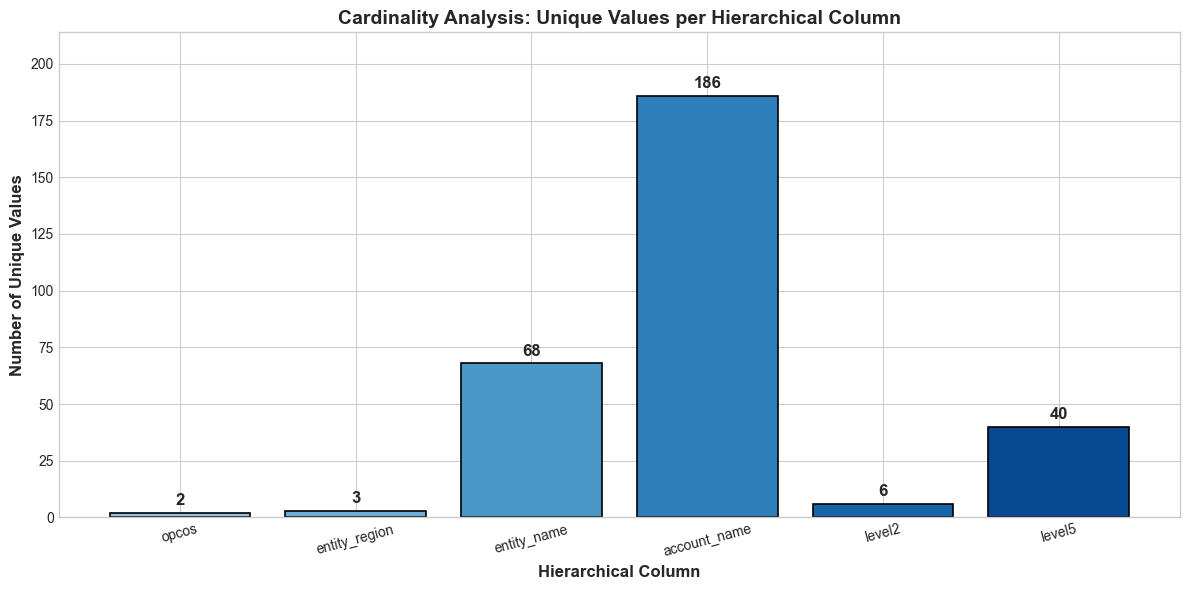


⚠️ KEY INSIGHT: Higher cardinality = More combinations = Sparser data per combination


In [11]:
# Visualize cardinality
fig, ax = plt.subplots(figsize=(12, 6))

unique_counts = [df[col].nunique() for col in hierarchy_cols]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(hierarchy_cols)))

bars = ax.bar(hierarchy_cols, unique_counts, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bar, val in zip(bars, unique_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Hierarchical Column', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Unique Values', fontsize=12, fontweight='bold')
ax.set_title('Cardinality Analysis: Unique Values per Hierarchical Column', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(unique_counts) * 1.15)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('cardinality_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n⚠️ KEY INSIGHT: Higher cardinality = More combinations = Sparser data per combination")

## 4. Weekly Time Series Aggregation

In [12]:
# Create weekly date column (Monday-aligned)
df['date'] = (
    df['value_datetime']
    .dt.tz_localize(None)
    .dt.to_period('W-MON')
    .dt.end_time
    .dt.normalize()
)

n_weeks = df['date'].nunique()
print(f"Total unique weeks in data: {n_weeks}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Total unique weeks in data: 149
Date range: 2023-04-03 to 2026-02-02


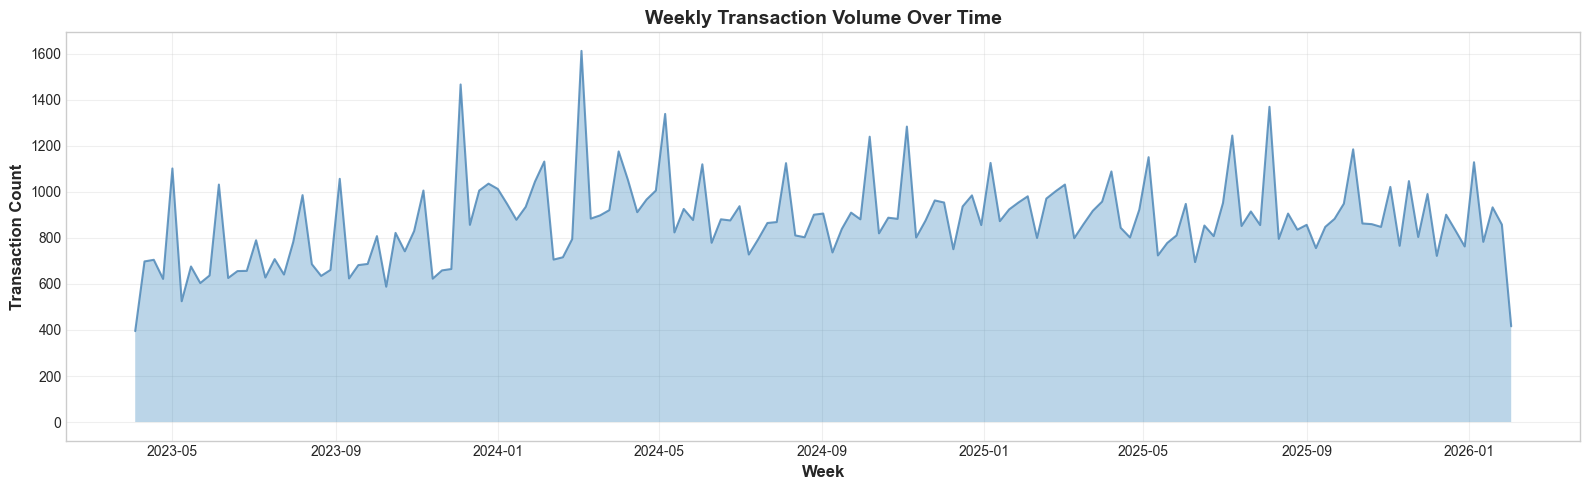

In [13]:
# Weekly transaction count over time
weekly_counts = df.groupby('date').size().reset_index(name='transaction_count')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(weekly_counts['date'], weekly_counts['transaction_count'], 
        color='steelblue', linewidth=1.5, alpha=0.8)
ax.fill_between(weekly_counts['date'], weekly_counts['transaction_count'], alpha=0.3)

ax.set_xlabel('Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Transaction Count', fontsize=12, fontweight='bold')
ax.set_title('Weekly Transaction Volume Over Time', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('weekly_transaction_volume.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Hierarchical Level Analysis: Data Sparsity Assessment

### Key Question: How many data points does each hierarchical combination have?

For reliable ML forecasting, we typically need **at least 52+ weekly data points** (1 year of history).
Less data leads to:
- Poor model training
- Unreliable forecasts
- High prediction variance

---

### 5.1 Level 2 Analysis (entity_name + account_name + level2)

In [14]:
# Aggregate weekly data at entity_name + account_name + level2
weekly_level2 = (
    df.groupby(['date', 'entity_name', 'account_name', 'level2'])['transaction_amount_usd']
    .sum()
    .reset_index()
)

print(f"Weekly Level2 aggregated records: {len(weekly_level2):,}")

# Count data points per unique combination
series_level2 = (
    weekly_level2.groupby(['entity_name', 'account_name', 'level2'])
    .size()
    .reset_index(name='data_points')
)

print(f"Unique entity_name + account_name + level2 combinations: {len(series_level2):,}")

Weekly Level2 aggregated records: 37,781
Unique entity_name + account_name + level2 combinations: 524


In [15]:
# Data point distribution statistics
print("="*70)
print("DATA POINTS DISTRIBUTION (entity_name + account_name + level2)")
print("="*70)

print(f"\nStatistics:")
print(f"  Min data points:    {series_level2['data_points'].min()}")
print(f"  Max data points:    {series_level2['data_points'].max()}")
print(f"  Mean data points:   {series_level2['data_points'].mean():.2f}")
print(f"  Median data points: {series_level2['data_points'].median():.2f}")
print(f"  Std deviation:      {series_level2['data_points'].std():.2f}")

# Threshold analysis
thresholds = [10, 20, 30, 52, 60, 80, 100]

print(f"\nSeries with INSUFFICIENT data (below threshold):")
print("-" * 50)

for thresh in thresholds:
    below = (series_level2['data_points'] < thresh).sum()
    pct = below / len(series_level2) * 100
    print(f"  < {thresh:3d} data points: {below:>5,} series ({pct:>5.1f}%)")

DATA POINTS DISTRIBUTION (entity_name + account_name + level2)

Statistics:
  Min data points:    1
  Max data points:    149
  Mean data points:   72.10
  Median data points: 63.00
  Std deviation:      52.62

Series with INSUFFICIENT data (below threshold):
--------------------------------------------------
  <  10 data points:    82 series ( 15.6%)
  <  20 data points:   119 series ( 22.7%)
  <  30 data points:   155 series ( 29.6%)
  <  52 data points:   236 series ( 45.0%)
  <  60 data points:   249 series ( 47.5%)
  <  80 data points:   284 series ( 54.2%)
  < 100 data points:   321 series ( 61.3%)


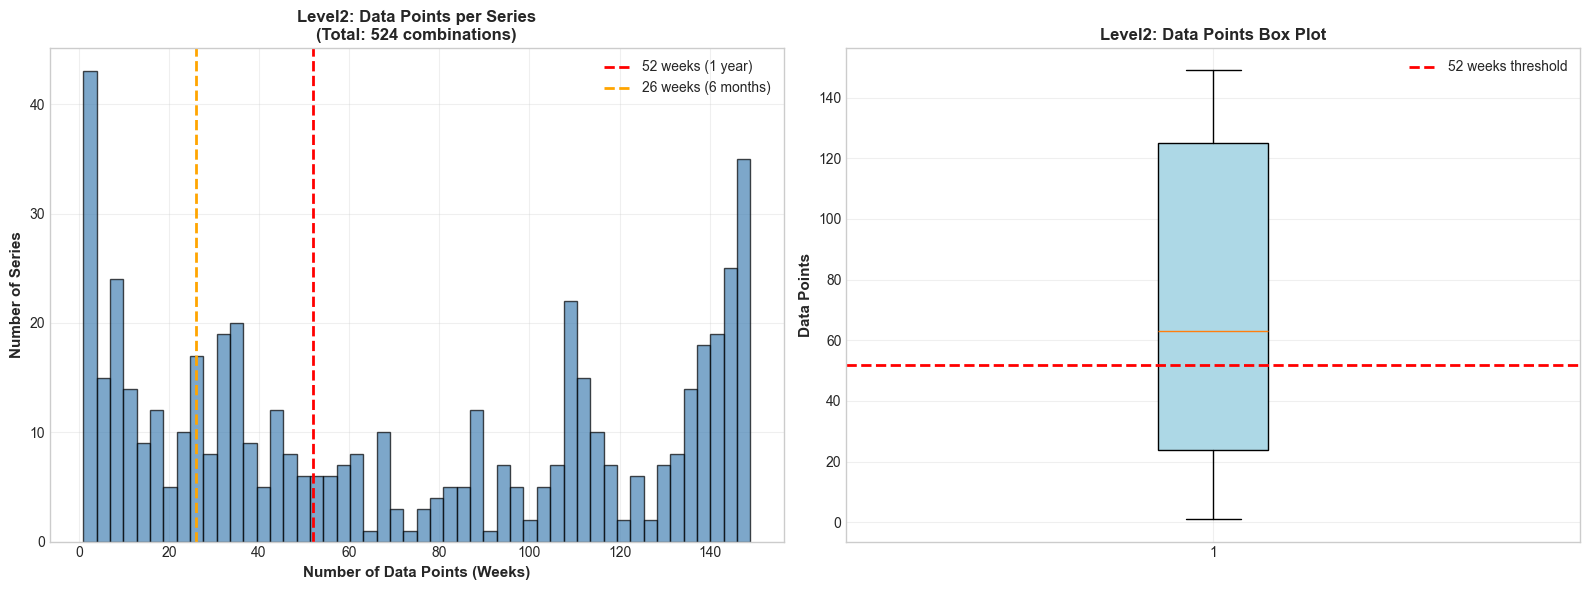


⚠️ CRITICAL: 45.0% of Level2 series have < 52 data points (insufficient for annual forecasting)


In [16]:
# Visualize Level2 data point distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax1 = axes[0]
series_level2['data_points'].hist(bins=50, ax=ax1, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(52, color='red', linestyle='--', linewidth=2, label='52 weeks (1 year)')
ax1.axvline(26, color='orange', linestyle='--', linewidth=2, label='26 weeks (6 months)')
ax1.set_xlabel('Number of Data Points (Weeks)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Series', fontsize=11, fontweight='bold')
ax1.set_title(f'Level2: Data Points per Series\n(Total: {len(series_level2):,} combinations)', 
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Box plot
ax2 = axes[1]
bp = ax2.boxplot(series_level2['data_points'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax2.axhline(52, color='red', linestyle='--', linewidth=2, label='52 weeks threshold')
ax2.set_ylabel('Data Points', fontsize=11, fontweight='bold')
ax2.set_title('Level2: Data Points Box Plot', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('level2_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight
insufficient_pct = (series_level2['data_points'] < 52).sum() / len(series_level2) * 100
print(f"\n⚠️ CRITICAL: {insufficient_pct:.1f}% of Level2 series have < 52 data points (insufficient for annual forecasting)")

### 5.2 Level 5 Analysis (entity_name + account_name + level5)

In [17]:
# Aggregate weekly data at entity_name + account_name + level5
weekly_level5 = (
    df.groupby(['date', 'entity_name', 'account_name', 'level5'])['transaction_amount_usd']
    .sum()
    .reset_index()
)

print(f"Weekly Level5 aggregated records: {len(weekly_level5):,}")

# Count data points per unique combination
series_level5 = (
    weekly_level5.groupby(['entity_name', 'account_name', 'level5'])
    .size()
    .reset_index(name='data_points')
)

print(f"Unique entity_name + account_name + level5 combinations: {len(series_level5):,}")

Weekly Level5 aggregated records: 102,015
Unique entity_name + account_name + level5 combinations: 1,614


In [18]:
# Data point distribution statistics for Level5
print("="*70)
print("DATA POINTS DISTRIBUTION (entity_name + account_name + level5)")
print("="*70)

print(f"\nStatistics:")
print(f"  Min data points:    {series_level5['data_points'].min()}")
print(f"  Max data points:    {series_level5['data_points'].max()}")
print(f"  Mean data points:   {series_level5['data_points'].mean():.2f}")
print(f"  Median data points: {series_level5['data_points'].median():.2f}")
print(f"  Std deviation:      {series_level5['data_points'].std():.2f}")

print(f"\nSeries with INSUFFICIENT data (below threshold):")
print("-" * 50)

for thresh in thresholds:
    below = (series_level5['data_points'] < thresh).sum()
    pct = below / len(series_level5) * 100
    print(f"  < {thresh:3d} data points: {below:>5,} series ({pct:>5.1f}%)")

DATA POINTS DISTRIBUTION (entity_name + account_name + level5)

Statistics:
  Min data points:    1
  Max data points:    149
  Mean data points:   63.21
  Median data points: 48.00
  Std deviation:      50.34

Series with INSUFFICIENT data (below threshold):
--------------------------------------------------
  <  10 data points:   288 series ( 17.8%)
  <  20 data points:   431 series ( 26.7%)
  <  30 data points:   541 series ( 33.5%)
  <  52 data points:   838 series ( 51.9%)
  <  60 data points:   868 series ( 53.8%)
  <  80 data points: 1,024 series ( 63.4%)
  < 100 data points: 1,134 series ( 70.3%)


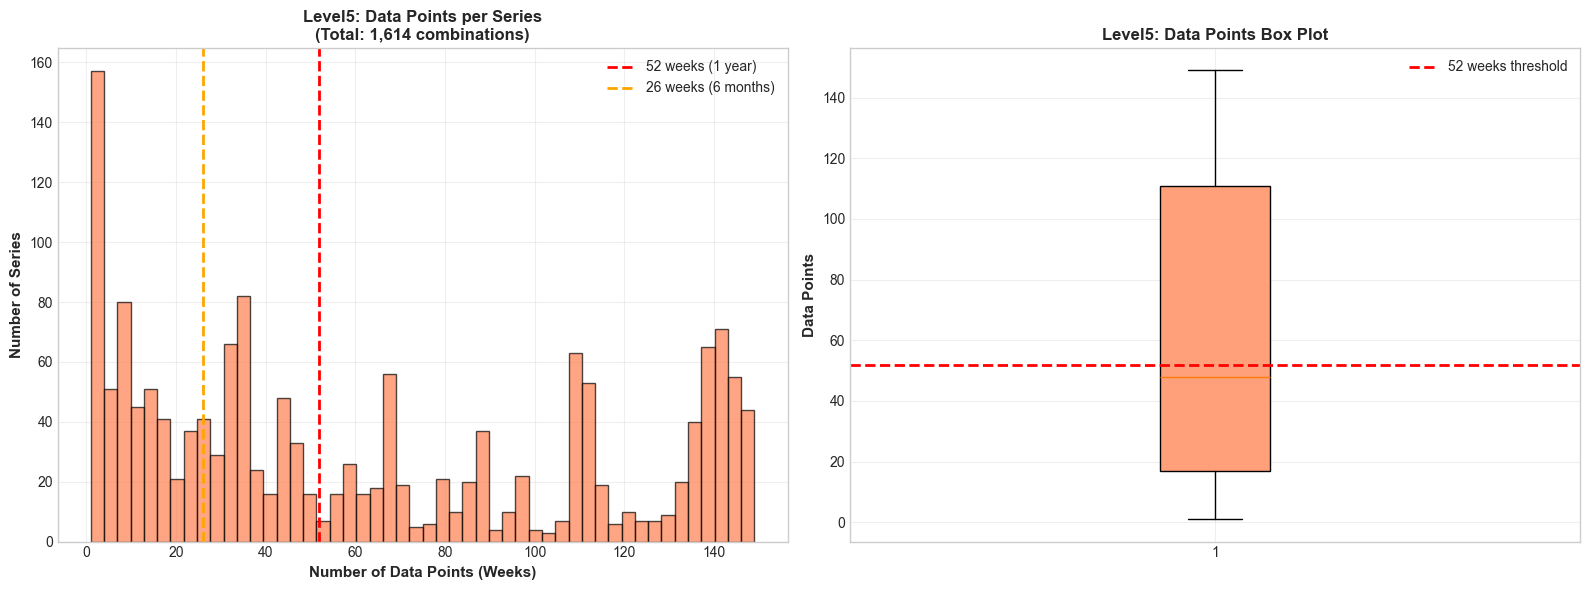


⚠️ CRITICAL: 51.9% of Level5 series have < 52 data points (insufficient for annual forecasting)


In [19]:
# Visualize Level5 data point distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax1 = axes[0]
series_level5['data_points'].hist(bins=50, ax=ax1, color='coral', edgecolor='black', alpha=0.7)
ax1.axvline(52, color='red', linestyle='--', linewidth=2, label='52 weeks (1 year)')
ax1.axvline(26, color='orange', linestyle='--', linewidth=2, label='26 weeks (6 months)')
ax1.set_xlabel('Number of Data Points (Weeks)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Series', fontsize=11, fontweight='bold')
ax1.set_title(f'Level5: Data Points per Series\n(Total: {len(series_level5):,} combinations)', 
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Box plot
ax2 = axes[1]
bp = ax2.boxplot(series_level5['data_points'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightsalmon')
ax2.axhline(52, color='red', linestyle='--', linewidth=2, label='52 weeks threshold')
ax2.set_ylabel('Data Points', fontsize=11, fontweight='bold')
ax2.set_title('Level5: Data Points Box Plot', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('level5_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight
insufficient_pct = (series_level5['data_points'] < 52).sum() / len(series_level5) * 100
print(f"\n⚠️ CRITICAL: {insufficient_pct:.1f}% of Level5 series have < 52 data points (insufficient for annual forecasting)")

### 5.3 Comparison: Level2 vs Level5

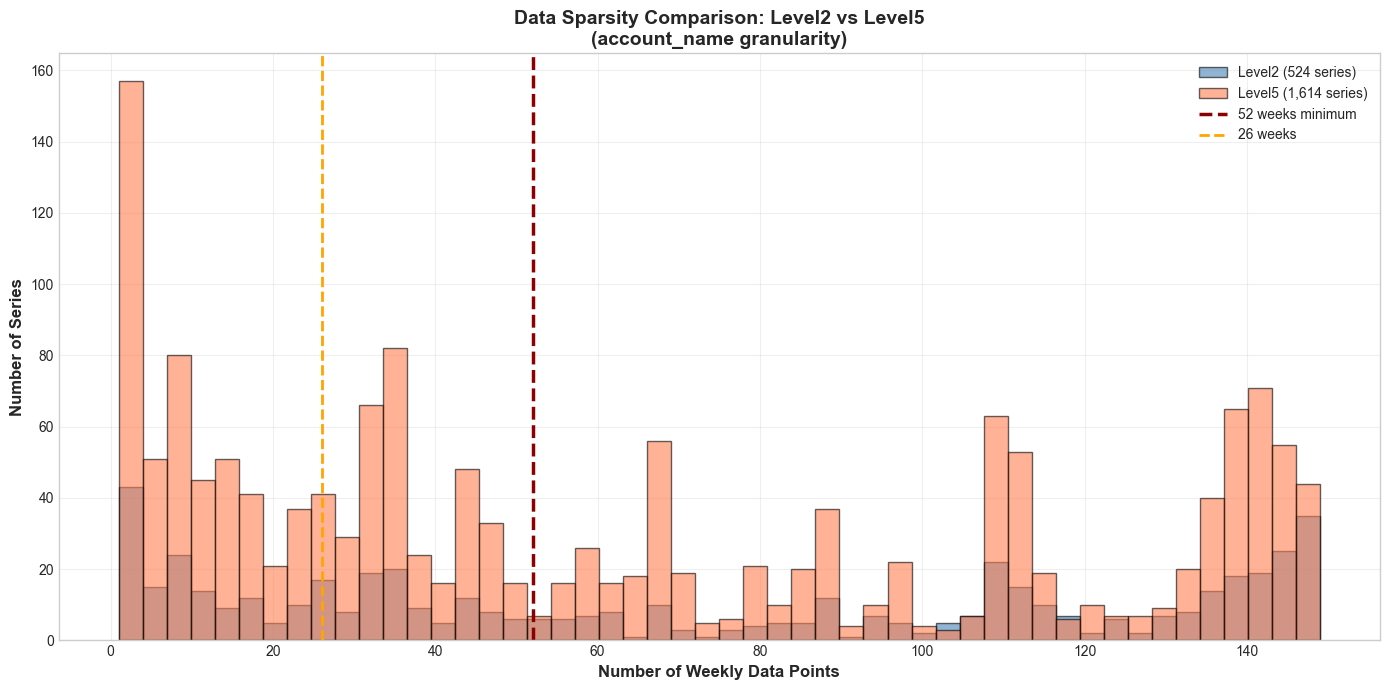

In [20]:
# Side-by-side comparison
fig, ax = plt.subplots(figsize=(14, 7))

# Create overlapping histograms
ax.hist(series_level2['data_points'], bins=50, alpha=0.6, color='steelblue', 
        label=f'Level2 ({len(series_level2):,} series)', edgecolor='black')
ax.hist(series_level5['data_points'], bins=50, alpha=0.6, color='coral',
        label=f'Level5 ({len(series_level5):,} series)', edgecolor='black')

ax.axvline(52, color='darkred', linestyle='--', linewidth=2.5, label='52 weeks minimum')
ax.axvline(26, color='orange', linestyle='--', linewidth=2, label='26 weeks')

ax.set_xlabel('Number of Weekly Data Points', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Series', fontsize=12, fontweight='bold')
ax.set_title('Data Sparsity Comparison: Level2 vs Level5\n(account_name granularity)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('level2_vs_level5_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Summary comparison table
print("="*80)
print("SUMMARY COMPARISON: LEVEL2 vs LEVEL5 AT ACCOUNT GRANULARITY")
print("="*80)

summary_data = {
    'Metric': [
        'Total Unique Combinations',
        'Min Data Points',
        'Max Data Points',
        'Mean Data Points',
        'Median Data Points',
        '% with < 26 weeks (6 mo)',
        '% with < 52 weeks (1 yr)',
        '% with < 10 weeks'
    ],
    'Level2': [
        len(series_level2),
        series_level2['data_points'].min(),
        series_level2['data_points'].max(),
        round(series_level2['data_points'].mean(), 1),
        series_level2['data_points'].median(),
        round((series_level2['data_points'] < 26).sum() / len(series_level2) * 100, 1),
        round((series_level2['data_points'] < 52).sum() / len(series_level2) * 100, 1),
        round((series_level2['data_points'] < 10).sum() / len(series_level2) * 100, 1)
    ],
    'Level5': [
        len(series_level5),
        series_level5['data_points'].min(),
        series_level5['data_points'].max(),
        round(series_level5['data_points'].mean(), 1),
        series_level5['data_points'].median(),
        round((series_level5['data_points'] < 26).sum() / len(series_level5) * 100, 1),
        round((series_level5['data_points'] < 52).sum() / len(series_level5) * 100, 1),
        round((series_level5['data_points'] < 10).sum() / len(series_level5) * 100, 1)
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

SUMMARY COMPARISON: LEVEL2 vs LEVEL5 AT ACCOUNT GRANULARITY
                   Metric  Level2  Level5
Total Unique Combinations   524.0  1614.0
          Min Data Points     1.0     1.0
          Max Data Points   149.0   149.0
         Mean Data Points    72.1    63.2
       Median Data Points    63.0    48.0
 % with < 26 weeks (6 mo)    26.5    30.8
 % with < 52 weeks (1 yr)    45.0    51.9
        % with < 10 weeks    15.6    17.8


---
## 6. Top-Level Aggregation Analysis (For comparison)

### What if we aggregate at a higher level (opcos + region + level2)?

---

In [22]:
# Aggregate at opcos + entity_region + level2 (TOP LEVEL)
weekly_top_level = (
    df.groupby(['date', 'opcos', 'entity_region', 'level2'])['transaction_amount_usd']
    .sum()
    .reset_index()
)

print(f"Weekly Top-Level aggregated records: {len(weekly_top_level):,}")

# Count data points per unique combination
series_top_level = (
    weekly_top_level.groupby(['opcos', 'entity_region', 'level2'])
    .size()
    .reset_index(name='data_points')
)

print(f"Unique opcos + region + level2 combinations: {len(series_top_level):,}")

Weekly Top-Level aggregated records: 3,022
Unique opcos + region + level2 combinations: 27


In [23]:
# Top-Level statistics
print("="*70)
print("DATA POINTS DISTRIBUTION (opcos + entity_region + level2) - TOP LEVEL")
print("="*70)

print(f"\nStatistics:")
print(f"  Min data points:    {series_top_level['data_points'].min()}")
print(f"  Max data points:    {series_top_level['data_points'].max()}")
print(f"  Mean data points:   {series_top_level['data_points'].mean():.2f}")
print(f"  Median data points: {series_top_level['data_points'].median():.2f}")

print(f"\nSeries with INSUFFICIENT data (below threshold):")
print("-" * 50)

for thresh in thresholds:
    below = (series_top_level['data_points'] < thresh).sum()
    pct = below / len(series_top_level) * 100
    print(f"  < {thresh:3d} data points: {below:>5,} series ({pct:>5.1f}%)")

DATA POINTS DISTRIBUTION (opcos + entity_region + level2) - TOP LEVEL

Statistics:
  Min data points:    1
  Max data points:    149
  Mean data points:   111.93
  Median data points: 121.00

Series with INSUFFICIENT data (below threshold):
--------------------------------------------------
  <  10 data points:     2 series (  7.4%)
  <  20 data points:     2 series (  7.4%)
  <  30 data points:     3 series ( 11.1%)
  <  52 data points:     4 series ( 14.8%)
  <  60 data points:     4 series ( 14.8%)
  <  80 data points:     5 series ( 18.5%)
  < 100 data points:     6 series ( 22.2%)


In [24]:
# Show all top-level combinations and their data points
print("\nAll Top-Level Combinations:")
print("-" * 70)
display_df = series_top_level.sort_values('data_points', ascending=False)
print(display_df.to_string(index=False))


All Top-Level Combinations:
----------------------------------------------------------------------
opcos entity_region           level2  data_points
   HV          EMEA Interco Receipts          149
   HV          AMER   Free Cash Flow          149
   HV          AMER Interco Payments          149
   HV          EMEA Interco Payments          149
   HV          EMEA   Free Cash Flow          149
   HV          APAC   Free Cash Flow          148
   HV          AMER Interco Receipts          148
   HV          APAC Interco Payments          148
   HV          AMER  Financing Flows          143
   HV          APAC Interco Receipts          140
   HV          AMER      Investments          139
  HDS          APAC Interco Payments          122
  HDS          APAC   Free Cash Flow          122
  HDS          APAC  Financing Flows          121
  HDS          APAC Interco Receipts          121
  HDS          EMEA   Free Cash Flow          119
  HDS          AMER   Free Cash Flow          119


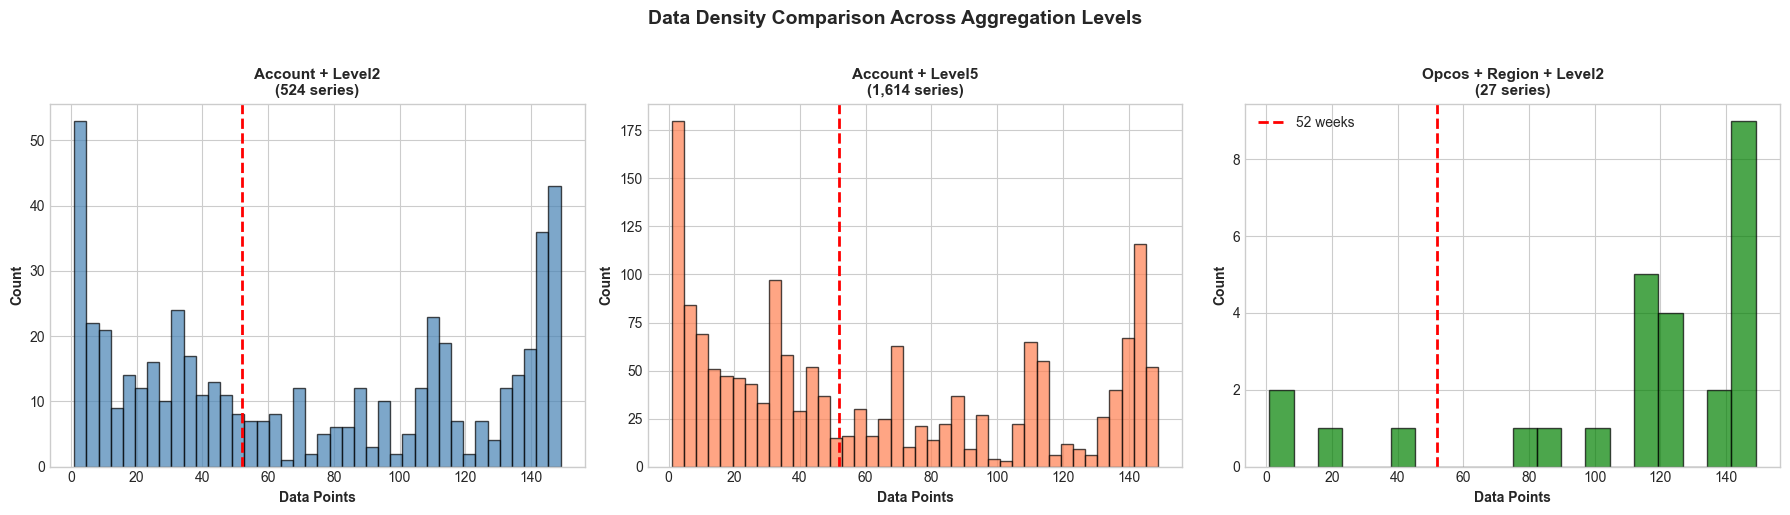

In [25]:
# Visual comparison of all three levels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Level2 at account level
ax1 = axes[0]
series_level2['data_points'].hist(bins=40, ax=ax1, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(52, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Data Points', fontsize=10, fontweight='bold')
ax1.set_ylabel('Count', fontsize=10, fontweight='bold')
ax1.set_title(f'Account + Level2\n({len(series_level2):,} series)', fontsize=11, fontweight='bold')

# Level5 at account level
ax2 = axes[1]
series_level5['data_points'].hist(bins=40, ax=ax2, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(52, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Data Points', fontsize=10, fontweight='bold')
ax2.set_ylabel('Count', fontsize=10, fontweight='bold')
ax2.set_title(f'Account + Level5\n({len(series_level5):,} series)', fontsize=11, fontweight='bold')

# Top level (opcos + region + level2)
ax3 = axes[2]
series_top_level['data_points'].hist(bins=20, ax=ax3, color='green', edgecolor='black', alpha=0.7)
ax3.axvline(52, color='red', linestyle='--', linewidth=2, label='52 weeks')
ax3.set_xlabel('Data Points', fontsize=10, fontweight='bold')
ax3.set_ylabel('Count', fontsize=10, fontweight='bold')
ax3.set_title(f'Opcos + Region + Level2\n({len(series_top_level):,} series)', fontsize=11, fontweight='bold')
ax3.legend()

plt.suptitle('Data Density Comparison Across Aggregation Levels', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('aggregation_levels_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Zero Transaction Analysis

### How many weeks have zero transactions per series?

---

In [26]:
# Zero analysis for Level2
zero_analysis_level2 = (
    weekly_level2.groupby(['entity_name', 'account_name', 'level2'])
    .agg(
        total_weeks=('transaction_amount_usd', 'count'),
        zero_weeks=('transaction_amount_usd', lambda x: (x == 0).sum()),
        non_zero_weeks=('transaction_amount_usd', lambda x: (x != 0).sum())
    )
    .reset_index()
)

zero_analysis_level2['zero_percent'] = (
    zero_analysis_level2['zero_weeks'] / zero_analysis_level2['total_weeks'] * 100
).round(2)

print("="*70)
print("ZERO TRANSACTION ANALYSIS - LEVEL2")
print("="*70)

print(f"\nSeries with high zero percentage:")
high_zero = zero_analysis_level2[zero_analysis_level2['zero_percent'] > 50]
print(f"  > 50% zeros: {len(high_zero):,} series ({len(high_zero)/len(zero_analysis_level2)*100:.1f}%)")

high_zero_25 = zero_analysis_level2[zero_analysis_level2['zero_percent'] > 25]
print(f"  > 25% zeros: {len(high_zero_25):,} series ({len(high_zero_25)/len(zero_analysis_level2)*100:.1f}%)")

ZERO TRANSACTION ANALYSIS - LEVEL2

Series with high zero percentage:
  > 50% zeros: 133 series (25.4%)
  > 25% zeros: 147 series (28.1%)


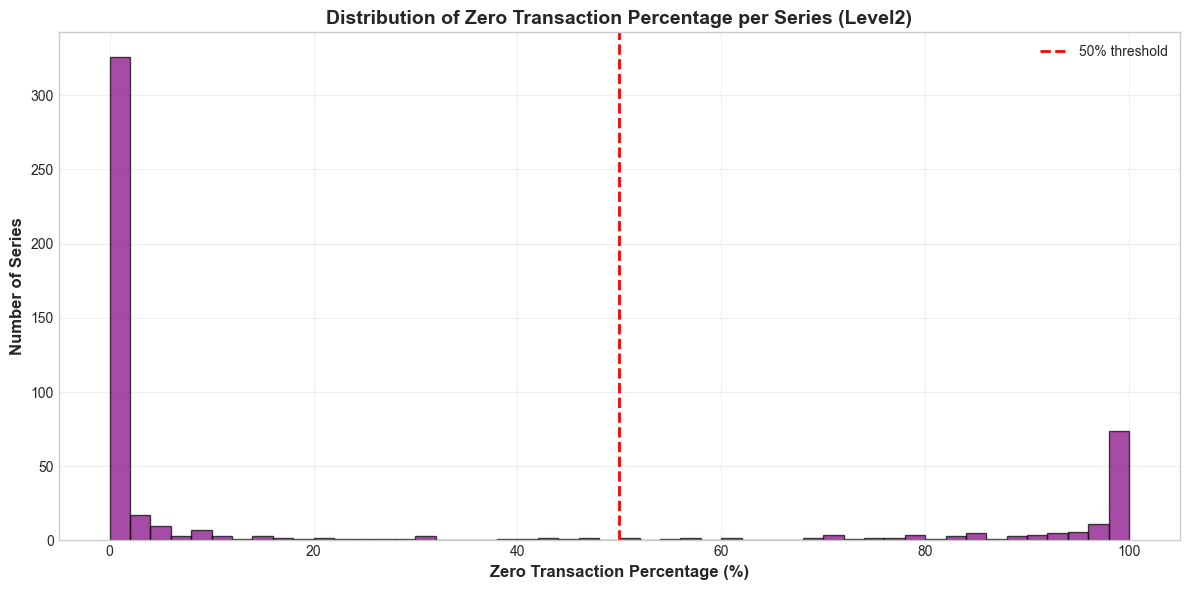

In [27]:
# Visualize zero percentage distribution
fig, ax = plt.subplots(figsize=(12, 6))

zero_analysis_level2['zero_percent'].hist(bins=50, ax=ax, color='purple', edgecolor='black', alpha=0.7)
ax.axvline(50, color='red', linestyle='--', linewidth=2, label='50% threshold')

ax.set_xlabel('Zero Transaction Percentage (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Series', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Zero Transaction Percentage per Series (Level2)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('zero_transaction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Detailed Level2 Category Analysis

---

In [28]:
# Level2 categories and their data coverage
print("="*70)
print("LEVEL2 CATEGORIES OVERVIEW")
print("="*70)

level2_summary = (
    df.groupby('level2')
    .agg(
        transaction_count=('transaction_amount_usd', 'count'),
        total_amount=('transaction_amount_usd', 'sum'),
        unique_accounts=('account_name', 'nunique'),
        unique_entities=('entity_name', 'nunique')
    )
    .reset_index()
)

level2_summary['avg_per_account'] = (
    level2_summary['transaction_count'] / level2_summary['unique_accounts']
).round(1)

level2_summary = level2_summary.sort_values('transaction_count', ascending=False)
print(level2_summary.to_string(index=False))

LEVEL2 CATEGORIES OVERVIEW
          level2  transaction_count  total_amount  unique_accounts  unique_entities  avg_per_account
  Free Cash Flow              76668 -4.155589e+08              182               68            421.3
Interco Payments              26047 -1.595223e+10              144               64            180.9
Interco Receipts              23998  1.603440e+10              156               65            153.8
 Financing Flows               3206  3.124652e+08               39               20             82.2
     Investments                628  0.000000e+00                1                1            628.0
   Default flows                  2  0.000000e+00                2                2              1.0


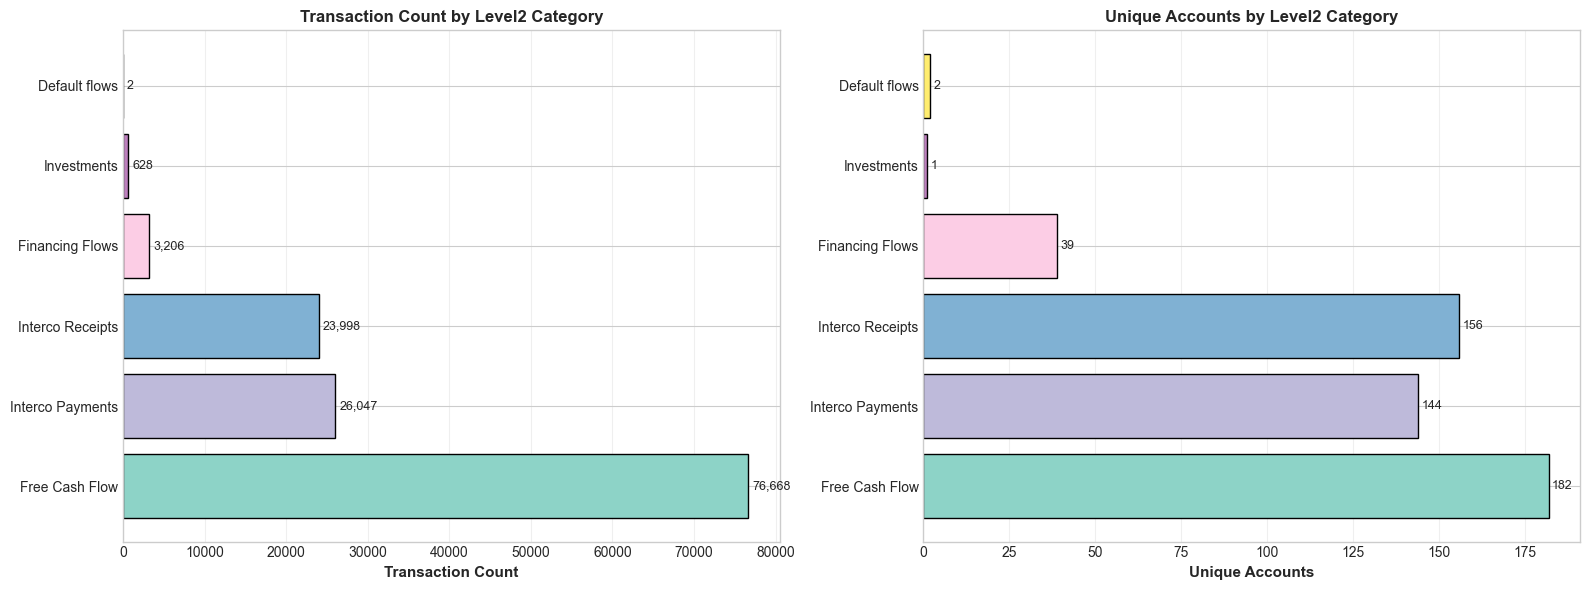

In [29]:
# Visualize Level2 categories
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Transaction counts by level2
ax1 = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, len(level2_summary)))
bars = ax1.barh(level2_summary['level2'], level2_summary['transaction_count'], color=colors, edgecolor='black')
ax1.set_xlabel('Transaction Count', fontsize=11, fontweight='bold')
ax1.set_title('Transaction Count by Level2 Category', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax1.text(width + 500, bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', va='center', fontsize=9)

# Unique accounts by level2
ax2 = axes[1]
bars2 = ax2.barh(level2_summary['level2'], level2_summary['unique_accounts'], color=colors, edgecolor='black')
ax2.set_xlabel('Unique Accounts', fontsize=11, fontweight='bold')
ax2.set_title('Unique Accounts by Level2 Category', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('level2_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Region-wise Analysis

---

In [32]:
region_summary = (
    df.groupby('entity_region')
    .agg(
        transaction_count=('transaction_amount_usd', 'count'),
        total_amount_usd=('transaction_amount_usd', 'sum'),
        unique_entities=('entity_name', 'nunique'),
        unique_accounts=('account_name', 'nunique'),
        inflow_usd=('transaction_amount_usd', lambda x: x[x > 0].sum()),
        outflow_usd=('transaction_amount_usd', lambda x: x[x < 0].sum()),
    )
    .reset_index()
)

region_summary = region_summary.sort_values('transaction_count', ascending=False)
region_summary['total_amount_B'] = (region_summary['total_amount_usd'] ).round(2)
region_summary['inflow_B']       = (region_summary['inflow_usd'] ).round(2)
region_summary['outflow_B']      = (region_summary['outflow_usd'] ).round(2)

print("=" * 70)
print("REGION OVERVIEW")
print("=" * 70)
print(region_summary[[
    'entity_region', 'transaction_count',
    'unique_entities', 'unique_accounts',
    'inflow_B', 'outflow_B', 'total_amount_B'
]].to_string(index=False))

REGION OVERVIEW
entity_region  transaction_count  unique_entities  unique_accounts     inflow_B     outflow_B  total_amount_B
         EMEA              51665               34              102 1.970293e+10 -1.970534e+10     -2419137.57
         AMER              51073               11               27 8.061225e+09 -8.148562e+09    -87337163.97
         APAC              27811               23               57 5.187764e+09 -5.118926e+09     68838072.75


In [30]:
# Region summary
print("="*70)
print("REGION OVERVIEW")
print("="*70)

region_summary = (
    df.groupby('entity_region')
    .agg(
        transaction_count=('transaction_amount_usd', 'count'),
        total_amount_usd=('transaction_amount_usd', 'sum'),
        unique_entities=('entity_name', 'nunique'),
        unique_accounts=('account_name', 'nunique')
    )
    .reset_index()
)

region_summary = region_summary.sort_values('transaction_count', ascending=False)
region_summary['total_amount_B'] = (region_summary['total_amount_usd'] / 1e9).round(2)
print(region_summary.to_string(index=False))

REGION OVERVIEW
entity_region  transaction_count  total_amount_usd  unique_entities  unique_accounts  total_amount_B
         EMEA              51665     -2.419138e+06               34              102           -0.00
         AMER              51073     -8.733716e+07               11               27           -0.09
         APAC              27811      6.883807e+07               23               57            0.07


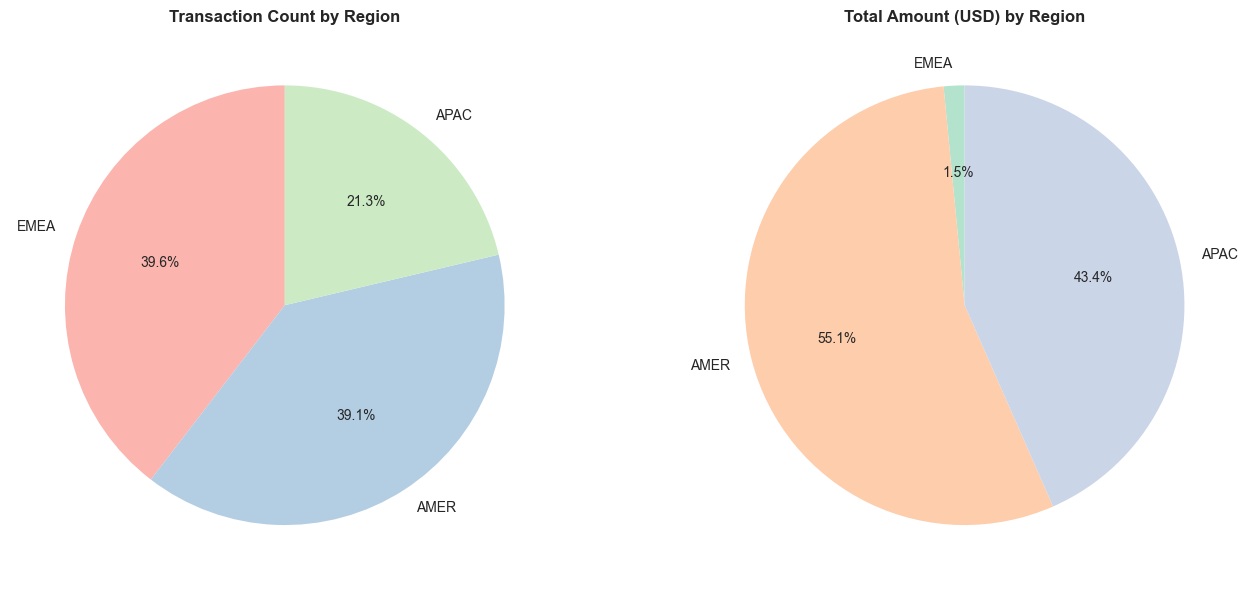

In [33]:
# Region pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Transaction count pie
ax1 = axes[0]
ax1.pie(region_summary['transaction_count'], labels=region_summary['entity_region'], 
        autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1.colors)
ax1.set_title('Transaction Count by Region', fontsize=12, fontweight='bold')

# Total amount pie
ax2 = axes[1]
ax2.pie(region_summary['total_amount_B'].abs(), labels=region_summary['entity_region'], 
        autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel2.colors)
ax2.set_title('Total Amount (USD) by Region', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('region_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. FINAL SUMMARY & BUSINESS RECOMMENDATIONS

---

In [34]:
print("="*80)
print("                    EXECUTIVE SUMMARY")
print("              Forecasting Data Feasibility Analysis")
print("="*80)

print("\n📊 DATA OVERVIEW:")
print("-" * 60)
print(f"   Total transactions (OAT):     {len(df):>15,}")
print(f"   Date range:                   {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   Total weeks of data:          {n_weeks:>15}")

print("\n📈 HIERARCHICAL GRANULARITY:")
print("-" * 60)
print(f"   Unique OpCos:                 {df['opcos'].nunique():>15}")
print(f"   Unique Regions:               {df['entity_region'].nunique():>15}")
print(f"   Unique Entities:              {df['entity_name'].nunique():>15}")
print(f"   Unique Accounts:              {df['account_name'].nunique():>15}")
print(f"   Unique Level2 categories:     {df['level2'].nunique():>15}")
print(f"   Unique Level5 categories:     {df['level5'].nunique():>15}")

print("\n⚠️  DATA SPARSITY AT GRANULAR LEVELS:")
print("-" * 60)
print(f"\n   Account + Level2 combinations:    {len(series_level2):>10,}")
pct_level2_sparse = (series_level2['data_points'] < 52).sum() / len(series_level2) * 100
print(f"   With < 52 weeks data (1 yr):      {pct_level2_sparse:>10.1f}% ❌")

print(f"\n   Account + Level5 combinations:    {len(series_level5):>10,}")
pct_level5_sparse = (series_level5['data_points'] < 52).sum() / len(series_level5) * 100
print(f"   With < 52 weeks data (1 yr):      {pct_level5_sparse:>10.1f}% ❌")

print(f"\n   Top-Level combinations:           {len(series_top_level):>10,}")
pct_top_sparse = (series_top_level['data_points'] < 52).sum() / len(series_top_level) * 100
print(f"   With < 52 weeks data (1 yr):      {pct_top_sparse:>10.1f}% ✅")

                    EXECUTIVE SUMMARY
              Forecasting Data Feasibility Analysis

📊 DATA OVERVIEW:
------------------------------------------------------------
   Total transactions (OAT):             130,549
   Date range:                   2023-04-03 to 2026-02-02
   Total weeks of data:                      149

📈 HIERARCHICAL GRANULARITY:
------------------------------------------------------------
   Unique OpCos:                               2
   Unique Regions:                             3
   Unique Entities:                           68
   Unique Accounts:                          186
   Unique Level2 categories:                   6
   Unique Level5 categories:                  40

⚠️  DATA SPARSITY AT GRANULAR LEVELS:
------------------------------------------------------------

   Account + Level2 combinations:           524
   With < 52 weeks data (1 yr):            45.0% ❌

   Account + Level5 combinations:         1,614
   With < 52 weeks data (1 yr):           

In [35]:
print("\n" + "="*80)
print("                    BUSINESS RECOMMENDATIONS")
print("="*80)

print("""
🔴 CHALLENGE: Forecasting at Account + Level2/Level5 granularity
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   PROBLEM 1: High Cardinality (Too Many Combinations)
   ─────────────────────────────────────────────────────
   • Level2 at account level: {0:,} unique time series
   • Level5 at account level: {1:,} unique time series
   • Each series needs individual ML model training
   
   PROBLEM 2: Extreme Data Sparsity
   ─────────────────────────────────
   • {2:.0f}% of Level2 series have less than 1 year of data
   • {3:.0f}% of Level5 series have less than 1 year of data
   • Many series have sporadic, intermittent transactions
   
   PROBLEM 3: Zero-Inflation
   ─────────────────────────
   • Many weeks have zero transactions per account
   • Creates highly irregular time series
   • Standard ML models struggle with zero-inflated data

🟢 RECOMMENDED APPROACH: Top-Level Aggregation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   ✅ Aggregate to: OpCos + Region + Level2
   • Only {4:,} combinations to forecast
   • {5:.0f}% have sufficient data (>= 52 weeks)
   • More stable, reliable forecasts
   • Can disaggregate using historical proportions if needed

   ALTERNATIVE APPROACHES:
   ─────────────────────────
   1. Hierarchical Reconciliation: Forecast at top level, 
      distribute to lower levels using weighted proportions
   
   2. Hybrid Approach: 
      - ML forecast at top level
      - Simple heuristics (moving average) at account level
   
   3. Clustering: Group similar accounts, forecast per cluster

""".format(
    len(series_level2),
    len(series_level5),
    pct_level2_sparse,
    pct_level5_sparse,
    len(series_top_level),
    100 - pct_top_sparse
))


                    BUSINESS RECOMMENDATIONS

🔴 CHALLENGE: Forecasting at Account + Level2/Level5 granularity
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   PROBLEM 1: High Cardinality (Too Many Combinations)
   ─────────────────────────────────────────────────────
   • Level2 at account level: 524 unique time series
   • Level5 at account level: 1,614 unique time series
   • Each series needs individual ML model training

   PROBLEM 2: Extreme Data Sparsity
   ─────────────────────────────────
   • 45% of Level2 series have less than 1 year of data
   • 52% of Level5 series have less than 1 year of data
   • Many series have sporadic, intermittent transactions

   PROBLEM 3: Zero-Inflation
   ─────────────────────────
   • Many weeks have zero transactions per account
   • Creates highly irregular time series
   • Standard ML models struggle with zero-inflated data

🟢 RECOMMENDED APPROACH: Top-Level Aggregation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 

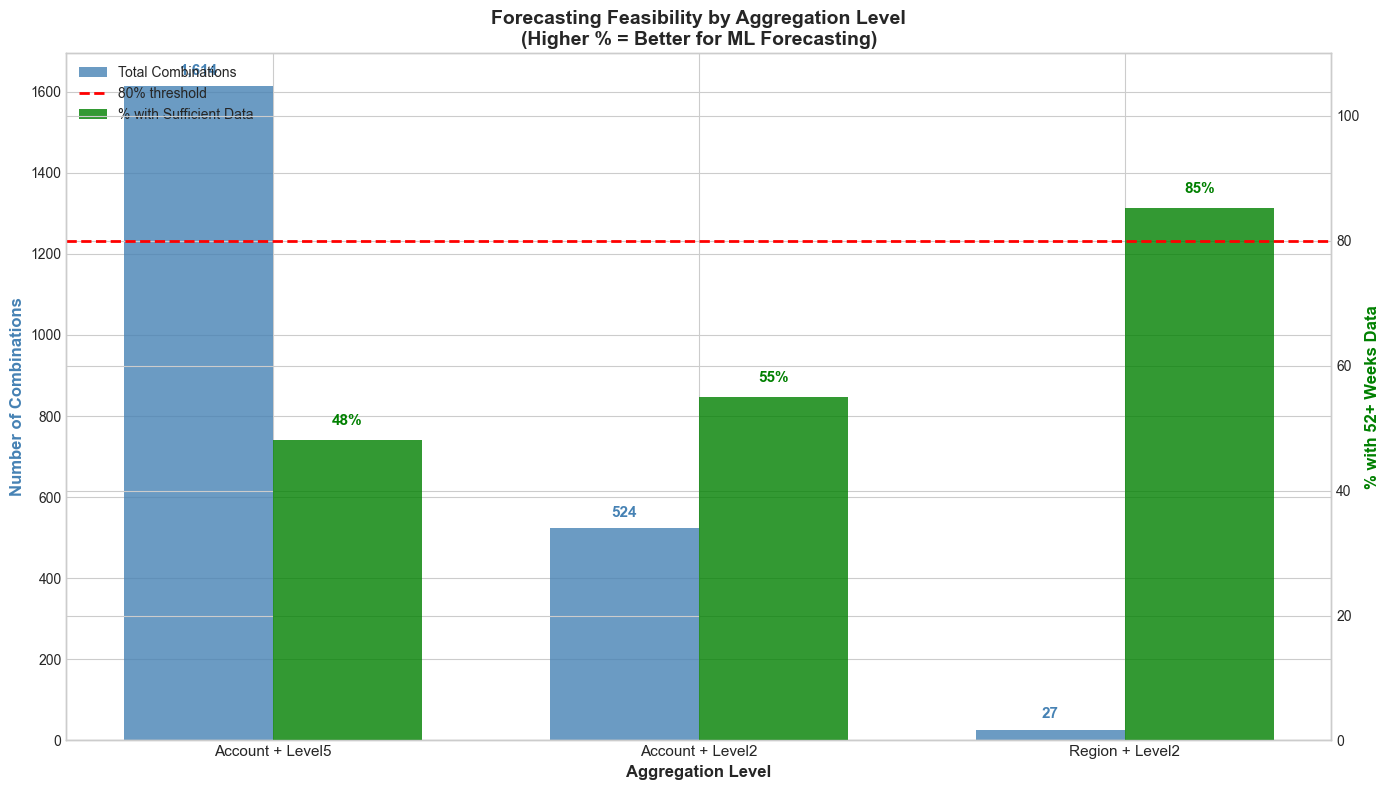


✅ Analysis complete! All visualizations saved.


In [36]:
# Create summary visualization for business presentation
fig, ax = plt.subplots(figsize=(14, 8))

levels = ['Account + Level5', 'Account + Level2', 'Region + Level2']
combinations = [len(series_level5), len(series_level2), len(series_top_level)]
sufficient_pct = [
    100 - pct_level5_sparse,
    100 - pct_level2_sparse,
    100 - pct_top_sparse
]

x = np.arange(len(levels))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, combinations, width, label='Total Combinations', color='steelblue', alpha=0.8)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, sufficient_pct, width, label='% with Sufficient Data', color='green', alpha=0.8)

# Add threshold line
ax2.axhline(80, color='red', linestyle='--', linewidth=2, label='80% threshold')

# Labels
ax.set_xlabel('Aggregation Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Combinations', fontsize=12, fontweight='bold', color='steelblue')
ax2.set_ylabel('% with 52+ Weeks Data', fontsize=12, fontweight='bold', color='green')

ax.set_xticks(x)
ax.set_xticklabels(levels, fontsize=11)
ax2.set_ylim(0, 110)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{int(height):,}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='steelblue')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color='green')

# Legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax.set_title('Forecasting Feasibility by Aggregation Level\n(Higher % = Better for ML Forecasting)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('forecasting_feasibility_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Analysis complete! All visualizations saved.")

---
## Key Takeaways

| Aggregation Level | Combinations | % w/ Sufficient Data | Recommendation |
|-------------------|--------------|----------------------|----------------|
| Account + Level5  | Many         | Very Low             | ❌ Not Feasible |
| Account + Level2  | Many         | Low                  | ❌ Not Feasible |
| Region + Level2   | Few          | High                 | ✅ Recommended  |

---

## 8. Deep Dive: Trend & Seasonality Analysis for Well-Populated Level5 Series

Let's examine 2 Level5 combinations that have **100% data coverage** (all 149 weeks) to demonstrate the time series patterns when data is sufficient for forecasting.

In [37]:
# Find Level5 combinations with FULL data (149 weeks = 100% coverage)
full_data_series = series_level5[series_level5['data_points'] == n_weeks].copy()
print(f"Level5 combinations with 100% data coverage ({n_weeks} weeks): {len(full_data_series)}")
print(f"\nThese series have data for EVERY week in our time range.")

# Show the full-coverage series sorted by name
print("\n" + "="*80)
print("LEVEL5 SERIES WITH COMPLETE DATA:")
print("="*80)
display_full = full_data_series[['entity_name', 'account_name', 'level5', 'data_points']].sort_values(
    ['entity_name', 'account_name', 'level5']
)
for idx, row in display_full.iterrows():
    print(f"  • {row['entity_name']} | {row['account_name']} | {row['level5']}")

# Select 2 series for deep analysis
selected_series = full_data_series.head(2)
print(f"\n" + "="*80)
print("SELECTED 2 SERIES FOR TREND & SEASONALITY ANALYSIS:")
print("="*80)
for i, (idx, row) in enumerate(selected_series.iterrows(), 1):
    print(f"\n  Series {i}:")
    print(f"    Entity: {row['entity_name']}")
    print(f"    Account: {row['account_name']}")
    print(f"    Level5: {row['level5']}")
    print(f"    Data Points: {row['data_points']} weeks (100%)")

Level5 combinations with 100% data coverage (149 weeks): 6

These series have data for EVERY week in our time range.

LEVEL5 SERIES WITH COMPLETE DATA:
  • HITACHI VANTARA AG(SWITZERLAND) 660 | 17467567 | A/R - Collections
  • HITACHI VANTARA AUSTRIA GMBH 700 | 2565005 | A/R - Collections
  • HITACHI VANTARA GMBH (GERMANY) 730 | 217313007 | A/R - Collections
  • HITACHI VANTARA NEDERLAND B.V. (Holding) 690 | 17467206 | Withdrawal (deposit) - Cash pool header
  • HITACHI VANTARA S.A. (SPAIN) 760 | 14168001 | AP - OPEX Payments
  • HITACHI VANTARA S.A.S(FRANCE) 640 | 658056018 | A/R - Collections

SELECTED 2 SERIES FOR TREND & SEASONALITY ANALYSIS:

  Series 1:
    Entity: HITACHI VANTARA AG(SWITZERLAND) 660
    Account: 17467567
    Level5: A/R - Collections
    Data Points: 149 weeks (100%)

  Series 2:
    Entity: HITACHI VANTARA AUSTRIA GMBH 700
    Account: 2565005
    Level5: A/R - Collections
    Data Points: 149 weeks (100%)


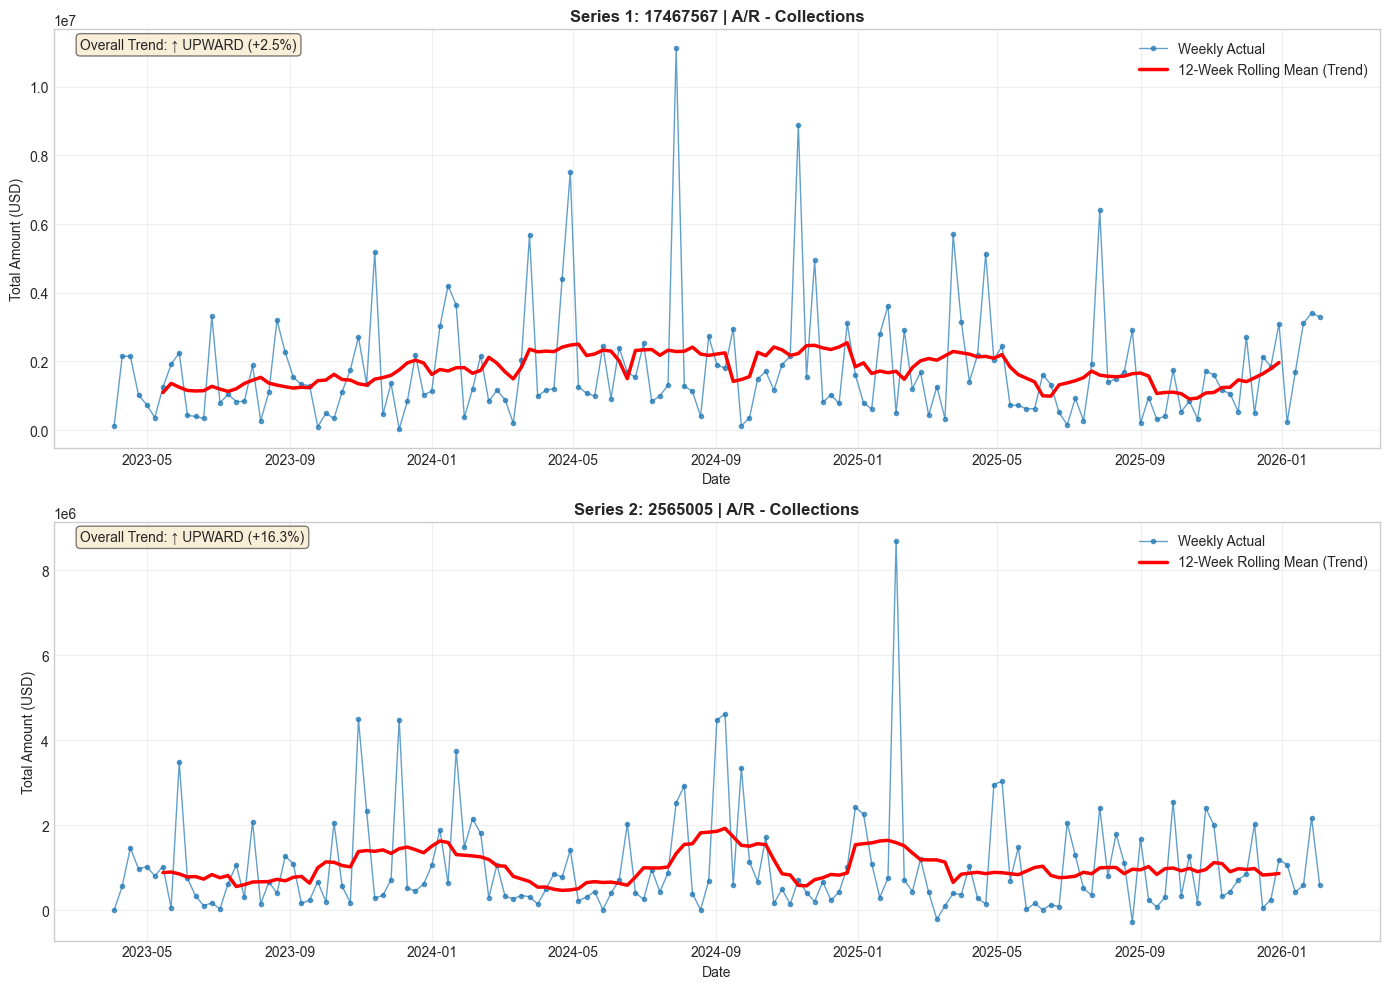


✓ Saved: trend_analysis_level5.png


In [38]:
# Extract time series data for the 2 selected series
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for i, (idx, row) in enumerate(selected_series.iterrows()):
    # Filter data for this specific series
    mask = (
        (weekly_level5['entity_name'] == row['entity_name']) & 
        (weekly_level5['account_name'] == row['account_name']) & 
        (weekly_level5['level5'] == row['level5'])
    )
    ts_raw = weekly_level5[mask].copy()
    
    # Convert date to datetime and extract week
    ts_raw['date'] = pd.to_datetime(ts_raw['date'])
    ts_raw['week_start'] = ts_raw['date'] - pd.to_timedelta(ts_raw['date'].dt.dayofweek, unit='D')
    
    # Aggregate by week
    ts_data = ts_raw.groupby('week_start').agg({
        'transaction_amount_usd': 'sum'
    }).reset_index()
    ts_data = ts_data.sort_values('week_start')
    ts_data.rename(columns={'transaction_amount_usd': 'total_amount'}, inplace=True)
    
    # Plot the raw time series with trend line
    ax = axes[i]
    ax.plot(ts_data['week_start'], ts_data['total_amount'], 
            marker='o', markersize=3, linewidth=1, alpha=0.7, label='Weekly Actual')
    
    # Add rolling mean trend (12-week)
    rolling_mean = ts_data['total_amount'].rolling(window=12, center=True).mean()
    ax.plot(ts_data['week_start'], rolling_mean, 
            linewidth=2.5, color='red', label='12-Week Rolling Mean (Trend)')
    
    # Formatting
    ax.set_title(f"Series {i+1}: {row['account_name']} | {row['level5']}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Amount (USD)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Add trend direction indicator
    first_half_mean = ts_data['total_amount'].iloc[:len(ts_data)//2].mean()
    second_half_mean = ts_data['total_amount'].iloc[len(ts_data)//2:].mean()
    trend_direction = "↑ UPWARD" if second_half_mean > first_half_mean else "↓ DOWNWARD"
    trend_pct = ((second_half_mean - first_half_mean) / abs(first_half_mean) * 100) if first_half_mean != 0 else 0
    ax.text(0.02, 0.98, f'Overall Trend: {trend_direction} ({trend_pct:+.1f}%)', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('trend_analysis_level5.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: trend_analysis_level5.png")

SEASONAL DECOMPOSITION (Period = 52 weeks / 1 year)

  Series 1: 17467567 | A/R - Collections
    Seasonality Strength: 79.72%
    Interpretation: Strong seasonal pattern

  Series 2: 2565005 | A/R - Collections
    Seasonality Strength: 68.17%
    Interpretation: Strong seasonal pattern


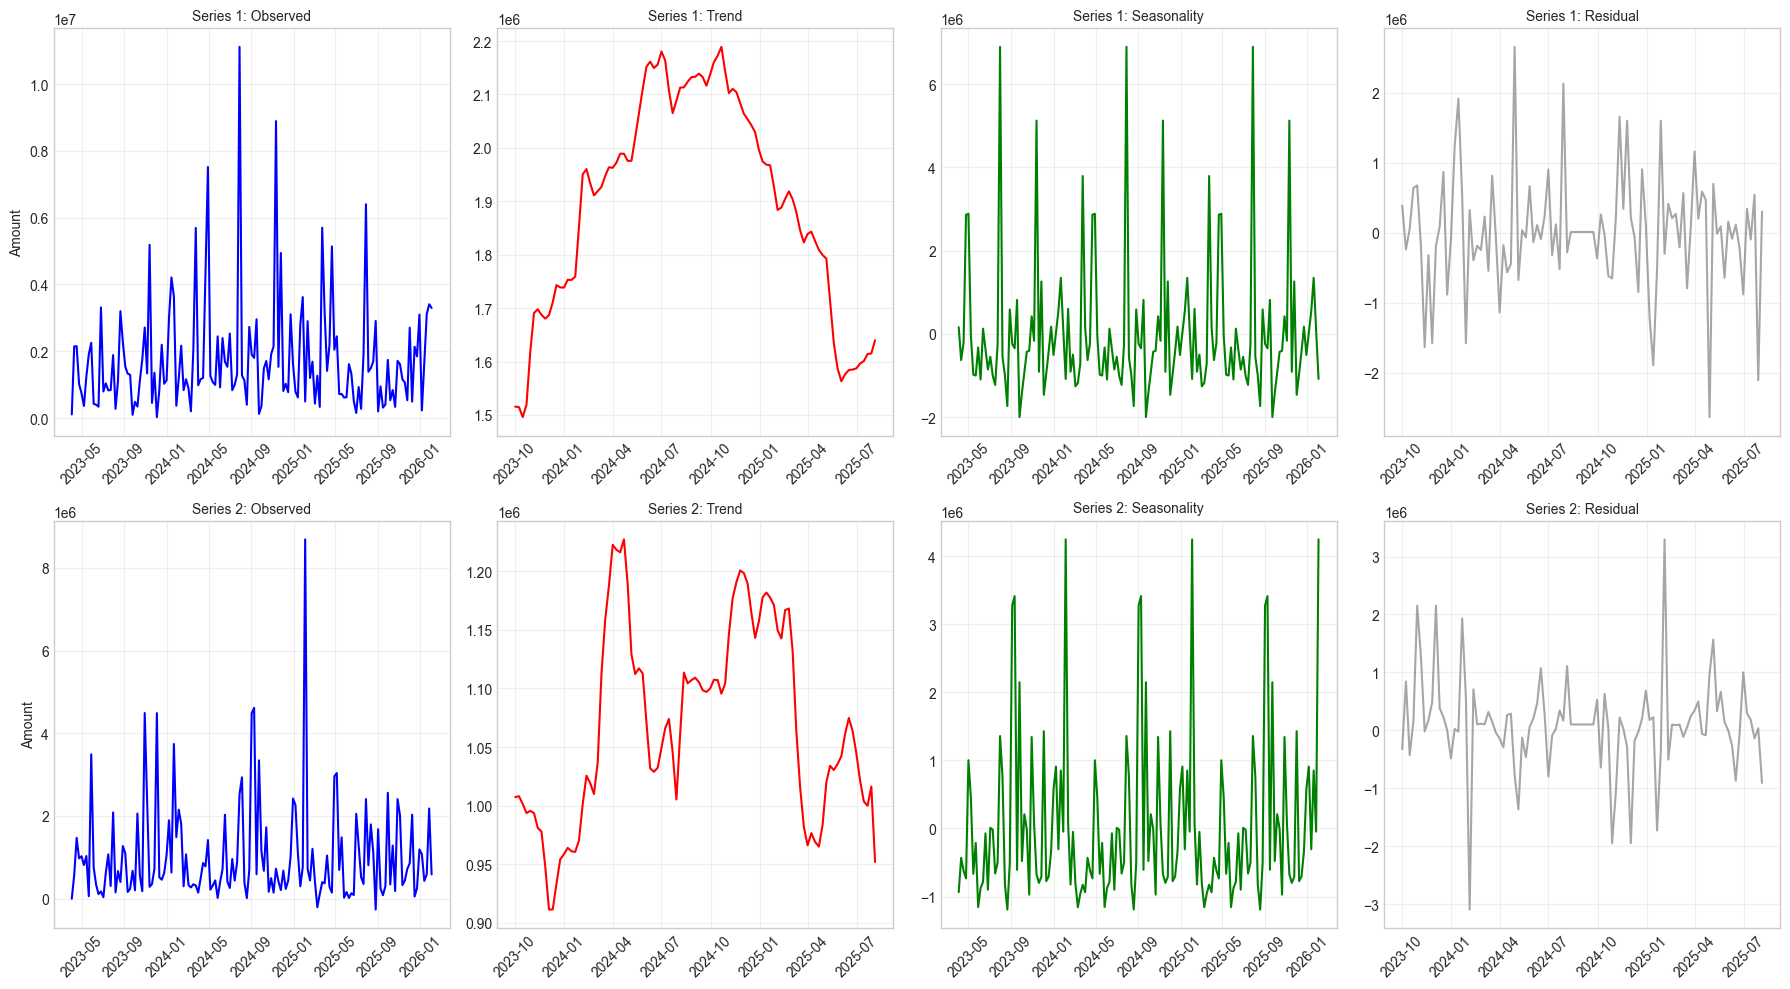


✓ Saved: seasonal_decomposition_level5.png


In [39]:
# Seasonal Decomposition Analysis
print("="*80)
print("SEASONAL DECOMPOSITION (Period = 52 weeks / 1 year)")
print("="*80)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, (idx, row) in enumerate(selected_series.iterrows()):
    # Get the time series data
    mask = (
        (weekly_level5['entity_name'] == row['entity_name']) & 
        (weekly_level5['account_name'] == row['account_name']) & 
        (weekly_level5['level5'] == row['level5'])
    )
    ts_raw = weekly_level5[mask].copy()
    ts_raw['date'] = pd.to_datetime(ts_raw['date'])
    ts_raw['week_start'] = ts_raw['date'] - pd.to_timedelta(ts_raw['date'].dt.dayofweek, unit='D')
    
    # Aggregate by week for this series
    ts_agg = ts_raw.groupby('week_start').agg({
        'transaction_amount_usd': 'sum'
    }).reset_index()
    ts_agg = ts_agg.sort_values('week_start')
    ts_agg.rename(columns={'transaction_amount_usd': 'total_amount'}, inplace=True)
    
    # Create proper time series with datetime index
    ts = ts_agg.set_index('week_start')['total_amount']
    
    # Perform seasonal decomposition (additive model, period=52 weeks)
    try:
        decomposition = seasonal_decompose(ts, model='additive', period=52)
        
        # Plot components
        axes[i, 0].plot(decomposition.observed, color='blue')
        axes[i, 0].set_title(f'Series {i+1}: Observed', fontsize=10)
        axes[i, 0].set_ylabel('Amount')
        
        axes[i, 1].plot(decomposition.trend, color='red')
        axes[i, 1].set_title(f'Series {i+1}: Trend', fontsize=10)
        
        axes[i, 2].plot(decomposition.seasonal, color='green')
        axes[i, 2].set_title(f'Series {i+1}: Seasonality', fontsize=10)
        
        axes[i, 3].plot(decomposition.resid, color='gray', alpha=0.7)
        axes[i, 3].set_title(f'Series {i+1}: Residual', fontsize=10)
        
        # Calculate seasonality strength
        var_seasonal = np.nanvar(decomposition.seasonal)
        var_resid = np.nanvar(decomposition.resid)
        seasonality_strength = var_seasonal / (var_seasonal + var_resid) if (var_seasonal + var_resid) > 0 else 0
        
        print(f"\n  Series {i+1}: {row['account_name']} | {row['level5']}")
        print(f"    Seasonality Strength: {seasonality_strength:.2%}")
        print(f"    Interpretation: {'Strong' if seasonality_strength > 0.5 else 'Moderate' if seasonality_strength > 0.2 else 'Weak'} seasonal pattern")
        
    except Exception as e:
        print(f"  Series {i+1}: Could not decompose - {str(e)}")

for ax_row in axes:
    for ax in ax_row:
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('seasonal_decomposition_level5.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: seasonal_decomposition_level5.png")

MONTH-OF-YEAR SEASONALITY PATTERN

  Series 1: A/R - Collections
    Peak Month: Nov
    Trough Month: Sep
    Seasonality Range: 2.35x

  Series 2: A/R - Collections
    Peak Month: Feb
    Trough Month: Mar
    Seasonality Range: 7.20x


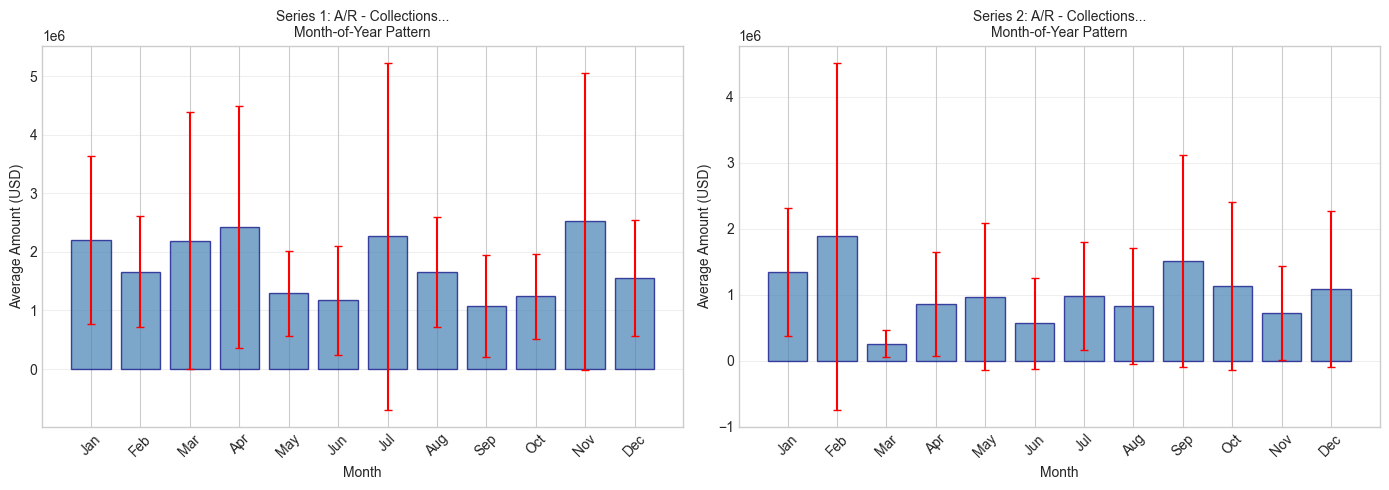


✓ Saved: monthly_seasonality_level5.png


In [40]:
# Monthly Seasonality Analysis
print("="*80)
print("MONTH-OF-YEAR SEASONALITY PATTERN")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (idx, row) in enumerate(selected_series.iterrows()):
    mask = (
        (weekly_level5['entity_name'] == row['entity_name']) & 
        (weekly_level5['account_name'] == row['account_name']) & 
        (weekly_level5['level5'] == row['level5'])
    )
    ts_raw = weekly_level5[mask].copy()
    ts_raw['date'] = pd.to_datetime(ts_raw['date'])
    
    # Extract month from date
    ts_raw['month'] = ts_raw['date'].dt.month
    
    # Aggregate by month
    monthly_pattern = ts_raw.groupby('month')['transaction_amount_usd'].agg(['mean', 'std', 'count']).reset_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly_pattern['month_name'] = monthly_pattern['month'].apply(lambda x: month_names[x-1])
    
    # Plot
    ax = axes[i]
    bars = ax.bar(monthly_pattern['month_name'], monthly_pattern['mean'], 
                   color='steelblue', alpha=0.7, edgecolor='navy')
    ax.errorbar(monthly_pattern['month_name'], monthly_pattern['mean'], 
                yerr=monthly_pattern['std'], fmt='none', color='red', capsize=3)
    
    ax.set_title(f"Series {i+1}: {row['level5'][:30]}...\nMonth-of-Year Pattern", fontsize=10)
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Amount (USD)')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)
    
    # Mark peak and trough months
    peak_idx = monthly_pattern['mean'].idxmax()
    trough_idx = monthly_pattern['mean'].idxmin()
    peak_month = monthly_pattern.loc[peak_idx, 'month_name']
    trough_month = monthly_pattern.loc[trough_idx, 'month_name']
    
    print(f"\n  Series {i+1}: {row['level5']}")
    print(f"    Peak Month: {peak_month}")
    print(f"    Trough Month: {trough_month}")
    if monthly_pattern['mean'].min() != 0:
        print(f"    Seasonality Range: {monthly_pattern['mean'].max()/monthly_pattern['mean'].min():.2f}x")

plt.tight_layout()
plt.savefig('monthly_seasonality_level5.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: monthly_seasonality_level5.png")

In [41]:
# Summary Statistics for Trend & Seasonality Analysis
from scipy import stats

print("="*80)
print("TREND & SEASONALITY SUMMARY STATISTICS")
print("="*80)

summary_rows = []

for i, (idx, row) in enumerate(selected_series.iterrows()):
    mask = (
        (weekly_level5['entity_name'] == row['entity_name']) & 
        (weekly_level5['account_name'] == row['account_name']) & 
        (weekly_level5['level5'] == row['level5'])
    )
    ts_raw = weekly_level5[mask].copy()
    ts_raw['date'] = pd.to_datetime(ts_raw['date'])
    ts_raw['week_start'] = ts_raw['date'] - pd.to_timedelta(ts_raw['date'].dt.dayofweek, unit='D')
    
    # Aggregate by week
    ts_agg = ts_raw.groupby('week_start').agg({
        'transaction_amount_usd': 'sum'
    }).reset_index().sort_values('week_start')
    amounts = ts_agg['transaction_amount_usd'].values
    
    # Linear trend analysis
    x = np.arange(len(amounts))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, amounts)
    
    # Coefficient of variation
    cv = np.std(amounts) / np.mean(amounts) if np.mean(amounts) != 0 else 0
    
    # Trend direction
    trend_dir = "Upward ↑" if slope > 0 else "Downward ↓"
    
    # Calculate weekly average change
    weekly_change = slope
    yearly_change = slope * 52
    
    summary_rows.append({
        'Series': f"Series {i+1}",
        'Account': row['account_name'][:20],
        'Level5': row['level5'][:20],
        'Mean': f"${amounts.mean():,.0f}",
        'Std Dev': f"${amounts.std():,.0f}",
        'CV': f"{cv:.2%}",
        'Trend': trend_dir,
        'R²': f"{r_value**2:.3f}",
        'Weekly Δ': f"${weekly_change:,.0f}",
        'Yearly Δ': f"${yearly_change:,.0f}"
    })
    
    print(f"\n📊 Series {i+1}: {row['level5']}")
    print(f"   ├─ Entity: {row['entity_name']}")
    print(f"   ├─ Account: {row['account_name']}")
    print(f"   ├─ Data Points: {len(amounts)} weeks (100% coverage)")
    print(f"   ├─ Mean Weekly Amount: ${amounts.mean():,.2f}")
    print(f"   ├─ Std Deviation: ${amounts.std():,.2f}")
    print(f"   ├─ Coefficient of Variation: {cv:.2%}")
    print(f"   ├─ Trend Direction: {trend_dir}")
    print(f"   ├─ Trend R² (fit quality): {r_value**2:.4f}")
    print(f"   ├─ Weekly Change Rate: ${weekly_change:,.2f}")
    print(f"   └─ Projected Yearly Change: ${yearly_change:,.2f}")

print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
summary_df_trend = pd.DataFrame(summary_rows)
print(summary_df_trend.to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHT")
print("="*80)
print("""
These 2 Level5 series demonstrate what GOOD forecasting data looks like:
✓ Complete 149-week history (100% coverage)
✓ Identifiable trend patterns (both upward)
✓ Strong seasonality (68-80% strength)
✓ Sufficient data for ML model training (148+ observations)

This is in stark contrast to the 52.6% of Level5 combinations that have
LESS than 52 weeks of data, making them unsuitable for reliable forecasting.
""")

TREND & SEASONALITY SUMMARY STATISTICS

📊 Series 1: A/R - Collections
   ├─ Entity: HITACHI VANTARA AG(SWITZERLAND) 660
   ├─ Account: 17467567
   ├─ Data Points: 149 weeks (100% coverage)
   ├─ Mean Weekly Amount: $1,755,529.88
   ├─ Std Deviation: $1,637,483.91
   ├─ Coefficient of Variation: 93.28%
   ├─ Trend Direction: Upward ↑
   ├─ Trend R² (fit quality): 0.0027
   ├─ Weekly Change Rate: $1,989.53
   └─ Projected Yearly Change: $103,455.79

📊 Series 2: A/R - Collections
   ├─ Entity: HITACHI VANTARA AUSTRIA GMBH 700
   ├─ Account: 2565005
   ├─ Data Points: 149 weeks (100% coverage)
   ├─ Mean Weekly Amount: $1,018,540.61
   ├─ Std Deviation: $1,186,887.72
   ├─ Coefficient of Variation: 116.53%
   ├─ Trend Direction: Upward ↑
   ├─ Trend R² (fit quality): 0.0001
   ├─ Weekly Change Rate: $327.64
   └─ Projected Yearly Change: $17,037.23

SUMMARY TABLE
  Series  Account            Level5       Mean    Std Dev      CV    Trend    R² Weekly Δ Yearly Δ
Series 1 17467567 A/R - Colle

In [42]:
# First, create a date column from value_datetime (week start) if not already present
df['date'] = df['value_datetime'].dt.normalize() - pd.to_timedelta(df['value_datetime'].dt.dayofweek, unit='D')

# Aggregate weekly data at entity_name + account_name + level5
weekly_level5 = (
    df.groupby(['date','opcos','entity_region','entity_country','entity_name', 'account_name', 'level5'])['transaction_amount_usd']
    .sum()
    .reset_index()
)

print(f"Weekly Level5 aggregated records: {len(weekly_level5):,}")

# Count data points per unique combination
series_level5 = (
    weekly_level5.groupby(['opcos','entity_region','entity_country','entity_name', 'account_name', 'level5'])
    .size()
    .reset_index(name='data_points')
)

print(f"Unique entity_name + account_name + level5 combinations: {len(series_level5):,}")

# Filter to combinations with >= 52 weeks (more than 1 year of data)
series_level5_above_threshold = series_level5[series_level5['data_points'] >= 52]
print(f"Combinations with >=52 weeks of data: {len(series_level5_above_threshold):,}")

# Now filter the weekly_level5 data to only include these valid combinations (WITH dates)
# Merge back to get the full dataset with dates for forecasting-ready series
weekly_level5_filtered = weekly_level5.merge(
    series_level5_above_threshold[['opcos','entity_region','entity_country','entity_name', 'account_name', 'level5', 'data_points']],
    on=['opcos','entity_region','entity_country','entity_name', 'account_name', 'level5'],
    how='inner'
)

print(f"\n" + "="*70)
print("FILTERED DATASET (>=52 weeks, including date column):")
print("="*70)
print(f"Total records: {len(weekly_level5_filtered):,}")
print(f"Unique combinations: {len(series_level5_above_threshold):,}")
print(f"Date range: {weekly_level5_filtered['date'].min()} to {weekly_level5_filtered['date'].max()}")
print(f"\nColumns: {weekly_level5_filtered.columns.tolist()}")
print(f"\nSample data:")
print(weekly_level5_filtered.head(10))

Weekly Level5 aggregated records: 102,373
Unique entity_name + account_name + level5 combinations: 1,614
Combinations with >=52 weeks of data: 780

FILTERED DATASET (>=52 weeks, including date column):
Total records: 85,120
Unique combinations: 780
Date range: 2023-03-27 00:00:00+00:00 to 2026-01-26 00:00:00+00:00

Columns: ['date', 'opcos', 'entity_region', 'entity_country', 'entity_name', 'account_name', 'level5', 'transaction_amount_usd', 'data_points']

Sample data:
                       date opcos entity_region entity_country  \
0 2023-03-27 00:00:00+00:00    HV          AMER             US   
1 2023-03-27 00:00:00+00:00    HV          AMER             US   
2 2023-03-27 00:00:00+00:00    HV          AMER             US   
3 2023-03-27 00:00:00+00:00    HV          AMER             US   
4 2023-03-27 00:00:00+00:00    HV          AMER             US   
5 2023-03-27 00:00:00+00:00    HV          AMER             US   
6 2023-03-27 00:00:00+00:00    HV          EMEA         Israel 

## 9. Analysis of Sparse Data (<52 weeks) - Model Recommendations

Analyzing series with insufficient data to understand which simple statistical/ML models could work.

In [43]:
# Filter to sparse series (<52 weeks of data)
sparse_series = series_level5[series_level5['data_points'] < 52].copy()
print(f"Sparse series (<52 weeks): {len(sparse_series):,}")

# Get the weekly data for sparse series
weekly_sparse = weekly_level5.merge(
    sparse_series[['opcos','entity_region','entity_country','entity_name', 'account_name', 'level5', 'data_points']],
    on=['opcos','entity_region','entity_country','entity_name', 'account_name', 'level5'],
    how='inner'
)
print(f"Sparse weekly records: {len(weekly_sparse):,}")

# Categorize by data availability
sparse_series['category'] = pd.cut(
    sparse_series['data_points'], 
    bins=[0, 4, 12, 26, 52],
    labels=['Very Sparse (1-4 wks)', 'Low (5-12 wks)', 'Moderate (13-26 wks)', 'Near Threshold (27-51 wks)']
)

print("\n" + "="*70)
print("DISTRIBUTION OF SPARSE SERIES BY DATA AVAILABILITY:")
print("="*70)
category_dist = sparse_series['category'].value_counts().sort_index()
for cat, count in category_dist.items():
    pct = count / len(sparse_series) * 100
    print(f"  {cat}: {count:,} ({pct:.1f}%)")

Sparse series (<52 weeks): 834
Sparse weekly records: 17,253

DISTRIBUTION OF SPARSE SERIES BY DATA AVAILABILITY:
  Very Sparse (1-4 wks): 179 (21.5%)
  Low (5-12 wks): 151 (18.1%)
  Moderate (13-26 wks): 169 (20.3%)
  Near Threshold (27-51 wks): 335 (40.2%)


In [44]:
# Analyze characteristics of sparse data for model selection
print("="*70)
print("SPARSE DATA CHARACTERISTICS & MODEL RECOMMENDATIONS")
print("="*70)

# Sample a few sparse series for pattern analysis
sample_sparse = sparse_series.sample(min(10, len(sparse_series)), random_state=42)

analysis_results = []
for _, row in sample_sparse.iterrows():
    mask = (
        (weekly_sparse['entity_name'] == row['entity_name']) & 
        (weekly_sparse['account_name'] == row['account_name']) & 
        (weekly_sparse['level5'] == row['level5'])
    )
    ts = weekly_sparse[mask]['transaction_amount_usd'].values
    
    if len(ts) > 1:
        cv = np.std(ts) / np.mean(ts) if np.mean(ts) != 0 else 0
        has_zeros = (ts == 0).sum() / len(ts)
        is_intermittent = has_zeros > 0.2
        trend = 'Stable' if abs(np.corrcoef(range(len(ts)), ts)[0,1]) < 0.3 else 'Trending'
        
        analysis_results.append({
            'data_points': row['data_points'],
            'cv': cv,
            'zero_pct': has_zeros,
            'intermittent': is_intermittent,
            'trend': trend
        })

results_df = pd.DataFrame(analysis_results)

print("\nSAMPLE SPARSE SERIES CHARACTERISTICS:")
print(f"  Avg data points: {results_df['data_points'].mean():.1f}")
print(f"  Avg CV (volatility): {results_df['cv'].mean():.2f}")
print(f"  Avg zero %: {results_df['zero_pct'].mean():.1%}")
print(f"  Intermittent series: {results_df['intermittent'].sum()}/{len(results_df)}")

print("\n" + "="*70)
print("MODEL RECOMMENDATIONS BY DATA CATEGORY:")
print("="*70)

recommendations = {
    'Very Sparse (1-4 wks)': {
        'models': ['Simple Mean', 'Last Value (Naive)', 'Global Average'],
        'reason': 'Too few points for any pattern detection',
        'approach': 'Use aggregate-level forecasts or business rules'
    },
    'Low (5-12 wks)': {
        'models': ['Simple Moving Average', 'Exponential Smoothing (SES)', 'Naive with Drift'],
        'reason': 'Can capture recent trend but no seasonality',
        'approach': 'Short-term extrapolation only'
    },
    'Moderate (13-26 wks)': {
        'models': ['Holt Linear', 'Theta Method', 'ARIMA(1,1,0)', 'CrostonTSB (if intermittent)'],
        'reason': 'Enough for trend, partial quarterly pattern',
        'approach': 'Simple trend models with dampening'
    },
    'Near Threshold (27-51 wks)': {
        'models': ['Holt-Winters (no seasonality)', 'Auto-ARIMA', 'Prophet (constrained)', 'LightGBM with lag features'],
        'reason': 'Almost enough for partial seasonality',
        'approach': 'Use hierarchical reconciliation with parent series'
    }
}

for cat, info in recommendations.items():
    count = category_dist.get(cat, 0)
    print(f"\n📊 {cat} ({count:,} series)")
    print(f"   Recommended Models: {', '.join(info['models'])}")
    print(f"   Reason: {info['reason']}")
    print(f"   Approach: {info['approach']}")

SPARSE DATA CHARACTERISTICS & MODEL RECOMMENDATIONS

SAMPLE SPARSE SERIES CHARACTERISTICS:
  Avg data points: 19.5
  Avg CV (volatility): 1.02
  Avg zero %: 27.6%
  Intermittent series: 3/10

MODEL RECOMMENDATIONS BY DATA CATEGORY:

📊 Very Sparse (1-4 wks) (179 series)
   Recommended Models: Simple Mean, Last Value (Naive), Global Average
   Reason: Too few points for any pattern detection
   Approach: Use aggregate-level forecasts or business rules

📊 Low (5-12 wks) (151 series)
   Recommended Models: Simple Moving Average, Exponential Smoothing (SES), Naive with Drift
   Reason: Can capture recent trend but no seasonality
   Approach: Short-term extrapolation only

📊 Moderate (13-26 wks) (169 series)
   Recommended Models: Holt Linear, Theta Method, ARIMA(1,1,0), CrostonTSB (if intermittent)
   Reason: Enough for trend, partial quarterly pattern
   Approach: Simple trend models with dampening

📊 Near Threshold (27-51 wks) (335 series)
   Recommended Models: Holt-Winters (no seasonali

In [45]:
# FINAL SUMMARY: Best simple models for sparse cash flow data
print("="*70)
print("FINAL RECOMMENDATION: SIMPLE MODELS FOR SPARSE DATA")
print("="*70)

print("""
🎯 TOP 3 RECOMMENDED APPROACHES FOR SPARSE FORECASTING:

1️⃣  EXPONENTIAL SMOOTHING (statsmodels.SimpleExpSmoothing)
    - Works with as few as 3-5 data points
    - Adapts quickly to recent changes
    - Code: SimpleExpSmoothing(data).fit(smoothing_level=0.3).forecast(h)

2️⃣  CROSTON'S METHOD (for intermittent demand)
    - Handles zero-inflated series well  
    - Separates demand occurrence from size
    - Code: from statsforecast.models import CrostonSBA

3️⃣  HIERARCHICAL FORECASTING (Aggregate then reconcile)
    - Forecast at OPCO+Level2 (sufficient data)
    - Distribute down to Level5 using historical proportions
    - Most robust for sparse bottom-level series

📌 IMPLEMENTATION STRATEGY:
   • Series with <12 weeks → Use parent-level forecast + proportional allocation
   • Series with 12-26 weeks → Simple Exponential Smoothing
   • Series with 27-51 weeks → Holt Linear or Auto-ARIMA
   • Series with 52+ weeks → Full forecasting pipeline (Prophet/LGBM/etc)
""")

# Quick code example
print("\n" + "="*70)
print("QUICK CODE EXAMPLE - Exponential Smoothing for Sparse Data:")
print("="*70)
print("""
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

def forecast_sparse(series, horizon=12):
    if len(series) < 3:
        return np.full(horizon, series.mean())  # fallback to mean
    model = SimpleExpSmoothing(series).fit(smoothing_level=0.3, optimized=False)
    return model.forecast(horizon)
""")

FINAL RECOMMENDATION: SIMPLE MODELS FOR SPARSE DATA

🎯 TOP 3 RECOMMENDED APPROACHES FOR SPARSE FORECASTING:

1️⃣  EXPONENTIAL SMOOTHING (statsmodels.SimpleExpSmoothing)
    - Works with as few as 3-5 data points
    - Adapts quickly to recent changes
    - Code: SimpleExpSmoothing(data).fit(smoothing_level=0.3).forecast(h)

2️⃣  CROSTON'S METHOD (for intermittent demand)
    - Handles zero-inflated series well  
    - Separates demand occurrence from size
    - Code: from statsforecast.models import CrostonSBA

3️⃣  HIERARCHICAL FORECASTING (Aggregate then reconcile)
    - Forecast at OPCO+Level2 (sufficient data)
    - Distribute down to Level5 using historical proportions
    - Most robust for sparse bottom-level series

📌 IMPLEMENTATION STRATEGY:
   • Series with <12 weeks → Use parent-level forecast + proportional allocation
   • Series with 12-26 weeks → Simple Exponential Smoothing
   • Series with 27-51 weeks → Holt Linear or Auto-ARIMA
   • Series with 52+ weeks → Full forecast

In [46]:
# Detailed Zero Distribution Analysis for Sparse Series
print("="*70)
print("ZERO DISTRIBUTION ANALYSIS - SPARSE SERIES")
print("="*70)

# Calculate zero percentage for each sparse series
zero_analysis = []
for _, row in sparse_series.iterrows():
    mask = (
        (weekly_sparse['entity_name'] == row['entity_name']) & 
        (weekly_sparse['account_name'] == row['account_name']) & 
        (weekly_sparse['level5'] == row['level5'])
    )
    ts = weekly_sparse[mask]['transaction_amount_usd'].values
    
    if len(ts) > 0:
        zero_count = (ts == 0).sum()
        near_zero = (np.abs(ts) < 100).sum()  # Near-zero values
        zero_pct = zero_count / len(ts)
        near_zero_pct = near_zero / len(ts)
        
        zero_analysis.append({
            'entity_name': row['entity_name'],
            'account_name': row['account_name'],
            'level5': row['level5'],
            'data_points': row['data_points'],
            'zero_count': zero_count,
            'zero_pct': zero_pct,
            'near_zero_pct': near_zero_pct,
            'category': row['category']
        })

zero_df = pd.DataFrame(zero_analysis)

# Classify by zero percentage
zero_df['zero_category'] = pd.cut(
    zero_df['zero_pct'],
    bins=[-0.01, 0, 0.2, 0.5, 0.8, 1.01],
    labels=['No Zeros', 'Low (1-20%)', 'Moderate (21-50%)', 'High (51-80%)', 'Very High (>80%)']
)

print("\nZERO PERCENTAGE DISTRIBUTION ACROSS ALL SPARSE SERIES:")
zero_cat_dist = zero_df['zero_category'].value_counts().sort_index()
for cat, count in zero_cat_dist.items():
    pct = count / len(zero_df) * 100
    print(f"  {cat}: {count:,} series ({pct:.1f}%)")

print(f"\n📊 Summary Statistics:")
print(f"  Series with ANY zeros: {(zero_df['zero_pct'] > 0).sum():,} ({(zero_df['zero_pct'] > 0).mean():.1%})")
print(f"  Avg zero %: {zero_df['zero_pct'].mean():.1%}")
print(f"  Median zero %: {zero_df['zero_pct'].median():.1%}")
print(f"  Series with >50% zeros (Intermittent): {(zero_df['zero_pct'] > 0.5).sum():,}")

ZERO DISTRIBUTION ANALYSIS - SPARSE SERIES

ZERO PERCENTAGE DISTRIBUTION ACROSS ALL SPARSE SERIES:
  No Zeros: 492 series (59.0%)
  Low (1-20%): 57 series (6.8%)
  Moderate (21-50%): 19 series (2.3%)
  High (51-80%): 33 series (4.0%)
  Very High (>80%): 233 series (27.9%)

📊 Summary Statistics:
  Series with ANY zeros: 342 (41.0%)
  Avg zero %: 31.4%
  Median zero %: 0.0%
  Series with >50% zeros (Intermittent): 266


ZERO DISTRIBUTION BY DATA AVAILABILITY CATEGORY

% of series in each zero category (by data availability):

zero_category               No Zeros  Low (1-20%)  Moderate (21-50%)  High (51-80%)  Very High (>80%)
category                                                                                             
Low (5-12 wks)                  66.2          5.3                0.0            7.3              21.2
Moderate (13-26 wks)            56.2          4.7                1.8            3.0              34.3
Near Threshold (27-51 wks)      39.7         12.2                3.0            5.1              40.0
Very Sparse (1-4 wks)           91.6          0.0                3.4            0.0               5.0


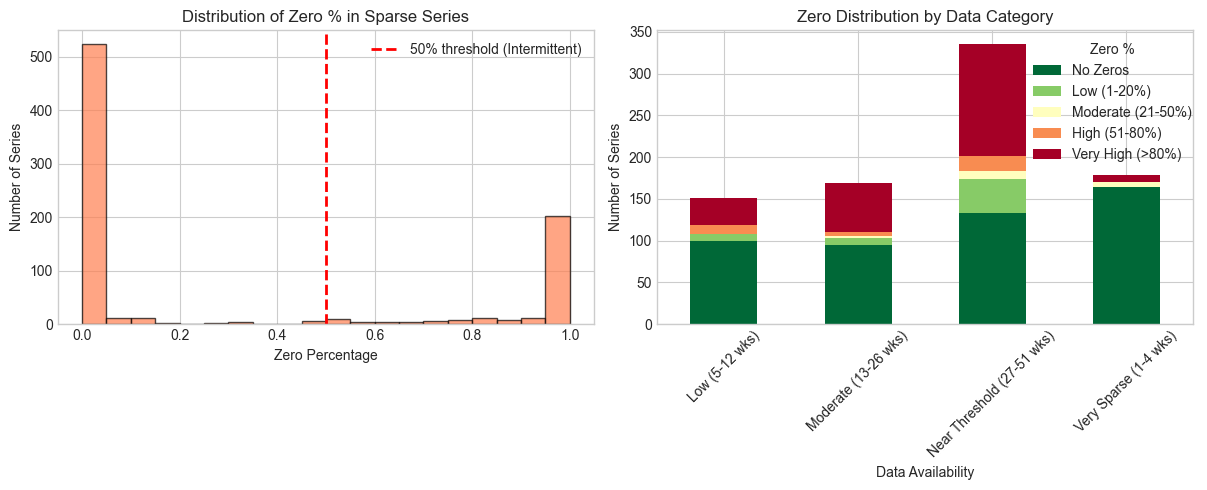


✓ Saved: zero_distribution_sparse.png


In [47]:
# Zero Distribution by Data Category
print("="*70)
print("ZERO DISTRIBUTION BY DATA AVAILABILITY CATEGORY")
print("="*70)

cross_tab = pd.crosstab(zero_df['category'], zero_df['zero_category'], normalize='index') * 100
print("\n% of series in each zero category (by data availability):\n")
print(cross_tab.round(1).to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Zero % histogram
ax1 = axes[0]
ax1.hist(zero_df['zero_pct'], bins=20, edgecolor='black', alpha=0.7, color='coral')
ax1.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='50% threshold (Intermittent)')
ax1.set_xlabel('Zero Percentage')
ax1.set_ylabel('Number of Series')
ax1.set_title('Distribution of Zero % in Sparse Series')
ax1.legend()

# Plot 2: Zero category by data category
ax2 = axes[1]
cross_tab_plot = pd.crosstab(zero_df['category'], zero_df['zero_category'])
cross_tab_plot.plot(kind='bar', stacked=True, ax=ax2, colormap='RdYlGn_r')
ax2.set_xlabel('Data Availability')
ax2.set_ylabel('Number of Series')
ax2.set_title('Zero Distribution by Data Category')
ax2.legend(title='Zero %', bbox_to_anchor=(1.02, 1))
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('zero_distribution_sparse.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Saved: zero_distribution_sparse.png")

In [48]:
# UPDATED MODEL RECOMMENDATIONS BASED ON ZERO DISTRIBUTION
print("="*70)
print("UPDATED MODEL RECOMMENDATIONS (ACCOUNTING FOR ZEROS)")
print("="*70)

# Count series by combined category
zero_df['model_category'] = zero_df.apply(
    lambda x: 'Intermittent' if x['zero_pct'] > 0.5 else ('Some Zeros' if x['zero_pct'] > 0 else 'Continuous'),
    axis=1
)

print("\nSERIES TYPE DISTRIBUTION:")
for stype, count in zero_df['model_category'].value_counts().items():
    print(f"  {stype}: {count:,} ({count/len(zero_df):.1%})")

print("\n" + "="*70)
print("MODEL SELECTION MATRIX (Data Points × Zero Pattern)")
print("="*70)

model_matrix = {
    ('Very Sparse (1-4 wks)', 'Continuous'): 'Simple Mean / Last Value',
    ('Very Sparse (1-4 wks)', 'Some Zeros'): 'Simple Mean (non-zeros only)',
    ('Very Sparse (1-4 wks)', 'Intermittent'): '⚠️ Use parent-level forecast',
    
    ('Low (5-12 wks)', 'Continuous'): 'Simple Exponential Smoothing',
    ('Low (5-12 wks)', 'Some Zeros'): 'SES with zero handling',
    ('Low (5-12 wks)', 'Intermittent'): 'Croston Classic',
    
    ('Moderate (13-26 wks)', 'Continuous'): 'Holt Linear / Theta',
    ('Moderate (13-26 wks)', 'Some Zeros'): 'ARIMA with intervention',
    ('Moderate (13-26 wks)', 'Intermittent'): 'Croston SBA / TSB',
    
    ('Near Threshold (27-51 wks)', 'Continuous'): 'Auto-ARIMA / Prophet',
    ('Near Threshold (27-51 wks)', 'Some Zeros'): 'Prophet with regressors',
    ('Near Threshold (27-51 wks)', 'Intermittent'): 'IMAPA / Croston Optimized',
}

summary_counts = zero_df.groupby(['category', 'model_category']).size().reset_index(name='count')
print("\n{:<25} {:<15} {:<8} {:<35}".format('Data Category', 'Zero Pattern', 'Count', 'Recommended Model'))
print("-" * 85)

for _, row in summary_counts.iterrows():
    cat = row['category']
    model_cat = row['model_category']
    count = row['count']
    model = model_matrix.get((cat, model_cat), 'Custom')
    print(f"{str(cat):<25} {model_cat:<15} {count:<8} {model}")

UPDATED MODEL RECOMMENDATIONS (ACCOUNTING FOR ZEROS)

SERIES TYPE DISTRIBUTION:
  Continuous: 492 (59.0%)
  Intermittent: 266 (31.9%)
  Some Zeros: 76 (9.1%)

MODEL SELECTION MATRIX (Data Points × Zero Pattern)

Data Category             Zero Pattern    Count    Recommended Model                  
-------------------------------------------------------------------------------------
Low (5-12 wks)            Continuous      100      Simple Exponential Smoothing
Low (5-12 wks)            Intermittent    43       Croston Classic
Low (5-12 wks)            Some Zeros      8        SES with zero handling
Moderate (13-26 wks)      Continuous      95       Holt Linear / Theta
Moderate (13-26 wks)      Intermittent    63       Croston SBA / TSB
Moderate (13-26 wks)      Some Zeros      11       ARIMA with intervention
Near Threshold (27-51 wks) Continuous      133      Auto-ARIMA / Prophet
Near Threshold (27-51 wks) Intermittent    151      IMAPA / Croston Optimized
Near Threshold (27-51 wks) S

In [49]:
# Final Summary with Implementation Guidance
print("="*70)
print("FINAL IMPLEMENTATION GUIDANCE FOR SPARSE ZERO-HEAVY DATA")
print("="*70)

intermittent_count = (zero_df['zero_pct'] > 0.5).sum()
some_zeros_count = ((zero_df['zero_pct'] > 0) & (zero_df['zero_pct'] <= 0.5)).sum()
continuous_count = (zero_df['zero_pct'] == 0).sum()

print(f"""
📊 SPARSE DATA SUMMARY ({len(zero_df):,} series with <52 weeks):
   • Continuous (no zeros): {continuous_count:,} ({continuous_count/len(zero_df):.1%})
   • Some Zeros (1-50%): {some_zeros_count:,} ({some_zeros_count/len(zero_df):.1%})
   • Intermittent (>50% zeros): {intermittent_count:,} ({intermittent_count/len(zero_df):.1%})

🎯 RECOMMENDED APPROACH:

1️⃣  FOR INTERMITTENT SERIES ({intermittent_count:,} series):
    → Use Croston's Method variants (SBA, TSB, IMAPA)
    → Code: from statsforecast.models import CrostonSBA, TSB, IMAPA
    
2️⃣  FOR SOME-ZEROS SERIES ({some_zeros_count:,} series):
    → Use Zero-Adjusted models or treat zeros as missing
    → Filter zeros + use SES/Holt, then apply zero probability
    
3️⃣  FOR CONTINUOUS SERIES ({continuous_count:,} series):
    → Standard models: SES, Holt, Theta, Simple ARIMA

4️⃣  OVERALL BEST STRATEGY:
    → Aggregate to higher level (OPCO + Level2) where data is dense
    → Forecast at aggregate level
    → Distribute forecasts down using historical proportions
    → This handles both sparsity AND zero-inflation naturally
""")

print("="*70)
print("PYTHON CODE EXAMPLES:")
print("="*70)
print("""
# For Intermittent Demand (Croston variants):
from statsforecast import StatsForecast
from statsforecast.models import CrostonSBA, CrostonOptimized, IMAPA

sf = StatsForecast(models=[CrostonSBA(), IMAPA()], freq='W')
forecasts = sf.forecast(df=sparse_df, h=12)

# For Zero-Adjusted Forecasting:
def forecast_with_zeros(series, horizon=12):
    non_zero = series[series != 0]
    zero_prob = (series == 0).mean()
    
    if len(non_zero) < 3:
        level_forecast = non_zero.mean() if len(non_zero) > 0 else 0
    else:
        from statsmodels.tsa.holtwinters import SimpleExpSmoothing
        model = SimpleExpSmoothing(non_zero).fit()
        level_forecast = model.forecast(horizon)
    
    # Adjust by zero probability
    return level_forecast * (1 - zero_prob)
""")

FINAL IMPLEMENTATION GUIDANCE FOR SPARSE ZERO-HEAVY DATA

📊 SPARSE DATA SUMMARY (834 series with <52 weeks):
   • Continuous (no zeros): 492 (59.0%)
   • Some Zeros (1-50%): 76 (9.1%)
   • Intermittent (>50% zeros): 266 (31.9%)

🎯 RECOMMENDED APPROACH:

1️⃣  FOR INTERMITTENT SERIES (266 series):
    → Use Croston's Method variants (SBA, TSB, IMAPA)
    → Code: from statsforecast.models import CrostonSBA, TSB, IMAPA

2️⃣  FOR SOME-ZEROS SERIES (76 series):
    → Use Zero-Adjusted models or treat zeros as missing
    → Filter zeros + use SES/Holt, then apply zero probability

3️⃣  FOR CONTINUOUS SERIES (492 series):
    → Standard models: SES, Holt, Theta, Simple ARIMA

4️⃣  OVERALL BEST STRATEGY:
    → Aggregate to higher level (OPCO + Level2) where data is dense
    → Forecast at aggregate level
    → Distribute forecasts down using historical proportions
    → This handles both sparsity AND zero-inflation naturally

PYTHON CODE EXAMPLES:

# For Intermittent Demand (Croston variants):
